# 17 — Revisão metodológica dos DLMs

Isabella Viana · TCC Estatística/UFSCar. Protocolo pré-interpretação em `docs/dlm_revisao_protocolo.md`, commit local1641dfd. Versão16 preservada; nenhuma reexecução de Granger ou SARIMAX. Este notebook executa os módulos da revisão quando `DLM_REPRODUZIR=1`; caso contrário, retoma somente após conferir hashes de entradas, código, protocolo e tabelas.

## 1. Objetivo da revisão

Identificar um perfil temporal defensável, sem procurar significância. Modelos por exposição e recorte, janela comparável e inferência sensível ao suporte.

In [1]:
from pathlib import Path
import os, sys, subprocess, json
ROOT = Path.cwd() if (Path.cwd()/'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT/'src'))
import pandas as pd, numpy as np
from IPython.display import display, Markdown, SVG
from dlm_revisao import *
from executar_dlm_revisao import run, resume
from dlm_revisao_relatorio import tables, summary
pd.set_option('display.max_columns', 12)
def show(name, cols=None, n=25):
    x=tables(name)
    display(x[cols].head(n) if cols else x.head(n))
    return None
print('Origem DLM: 3c94482628b86d1789ee98f8d35f6820835a7219')

Origem DLM: 3c94482628b86d1789ee98f8d35f6820835a7219


## 2. Limitações identificadas

O BIC de DLM irrestrito penaliza13 parâmetros em K12 versus4 em K3. Isso não estima duração. A inferência convencional pode ser frágil com exposição concentrada; recortes se sobrepõem. As decisões da revisão foram registradas antes dos novos resultados.

In [2]:
display(Markdown((ROOT/'docs/dlm_revisao_protocolo.md').read_text()))

# Protocolo da revisão DLM — registrado antes dos novos modelos

Data: 2026-10-03. Origem: `analise/dlm`, commit `3c94482628b86d1789ee98f8d35f6820835a7219`; main `027ee8aa245494765d99bff2511b6f60b30ddf41`. PR #4 aberto, sem comentários. Notebook 16, src/dlm.py e saídas históricas ficam preservados. Granger será apenas lido. SARIMAX não será executado.

## Auditoria e estimando

27 UFs × 144 meses (2013–2024); pré até jan/2020 inclusive. Dependente principal: primeira diferença de `100 CI/CA`, em pontos percentuais. Não se usam meses anteriores ao início de 2013; lags construídos antes de excluir observações da robustez pandêmica, sem preencher intervalos. Primeira observação utilizável principal: jan/2014; pré tem 73 meses; total, 132 meses.

A = linhas/registros originais; B = ocorrências **municipais** distintas pela chave UF + código IBGE municipal + data exata do evento + COBRADE. Não é identificação de tempestades meteorológicas únicas: um evento regional pode atingir muitos municípios. A auditoria encontra 101 repetições da chave, nenhuma linha exata duplicada; campos de grupo/tipologia consistentes nas chaves. B é uma aproximação auditável, não certeza de duplicidade administrativa. Linhagem fica local; contagens públicas agregadas.

C = municípios distintos com registro na UF-mês, independentemente de repetição; C_prop = C/número de municípios (base territorial 2022 fixa). **Principal: C_prop em escala 0–1**, sem log. Ela mede cobertura municipal relativa documentada, não população, área, gravidade ou exposição física objetiva. Escolhida pela interpretação de extensão da exposição e menor sensibilidade a repetição administrativa, antes de p-valores. A e B com log1p e C com log1p são sensibilidades. Mudança de exposição muda o estimando e sua unidade; comparar cenários plausíveis, não coeficientes brutos de unidades diferentes.

Denominadores: tabela IBGE 2022, reproduzida pela FAPESPA; soma 5570, inclui DF e Fernando de Noronha como unidades equivalentes. O IBGE documenta estabilidade do número de municípios desde 2013 até 2021. Não usar divisão territorial posterior a 2024. Fonte: https://www.fapespa.pa.gov.br/sistemas/pcn2023/tabelas/1-territorio/1-numero-de-municipio-e-area-territorial-2022.htm e https://www.agenciadenoticias.ibge.gov.br/agencia-sala-de-imprensa/2013-agencia-de-noticias/releases/33005-ibge-atualiza-lista-de-municipios-distritos-e-subdistritos-municipais-do-pais-3

## Taxonomia

Original preservada: total, quatro grupos, 16 tipologias. Não há hierarquia única tipologia→grupo. COBRADE 12/13/14: clima/hidrometeorologia; 11/15: natural não diretamente climático; 2: tecnológico/antrópico. Criam-se três agregados analíticos. Movimentos de massa e erosão podem ser influenciados por chuva, mas código não certifica gatilho; biológico não é automaticamente clima. Incêndio pode ter origem antrópica mesmo com código climatológico. Nenhuma categoria removida. Chuvas Intensas com 13310 e Onda de Frio com 13120 são inconsistências nome/código explícitas; agregados por código são sensibilidades substantivas, não correções silenciosas.

## Suporte (antes de resultados)

Por exposição/medida/período: ocorrências B, soma da medida, zeros, skew, UF-mês positivos, UFs, meses, top1/top2, HHI espacial e temporal, top mês, variação within, N_eff=1/HHI. N_eff de cobertura proporcional não é df inferencial. Calcular também métricas na amostra efetiva após lags.

Não estimável: B<24, UF-mês positivos<12, UFs<5, meses<8 ou variação within≈0. Alta concentração: N_eff<5, top1>50%, top2>80% ou top mês>25%, desde que atinja suporte mínimo. Estimável: B≥100, células≥50, UFs≥10, meses≥24, N_eff≥10 e top1≤30%; restante com ressalvas. Alta concentração é estimada descritivamente, com força interpretativa limitada; não é excluída para buscar resultado nulo ou significativo. Rank completo da matriz residualizada e graus de liberdade positivos obrigatórios.

## Especificações

Principal: UF FE + mês-ano FE, não ponderado; identifica exposição relativa dentro de mês, líquida de diferenças permanentes. Associação para UF média; não é efeito causal, pois há confundidores UF-tempo e possíveis spillovers.

K_max=12, perfil específico de cada exposição. Base natural cúbica `patsy.cr(lag,df=J)` sem restrição de centralização, J∈{3,4}; coeficiente spline inclui componente constante no perfil de lags (não um intercepto duplicado da equação). Z_j=Σ_k X_(t-k)B_j(k); β=Bθ, Vβ=B Vθ B'. BIC em amostra idêntica, J menor desempata. Reportar AIC/BIC e ambos os perfis; inferência condicionada à base escolhida, não corrige seleção de J. Estabilidade entre J é obrigatória para alegar robustez. Principal comparável também com J=3 fixo como sensibilidade.

Quantidades: β0, Σ1..12β, Σ0..12β; C(h) com covariância completa. Pulso isolado: C(h) resume mudança da taxa, condicional ao modelo; não confundir com aumento permanente de exposição. Bandas simultâneas condicionais: simulação t multivariada da covariância cluster, 9999 draws, max-|t| ao longo dos 13 horizontes; cobertura aproximada, não ajustada entre exposições nem pela seleção de J.

Horizontes secundários ex ante: súbitos (alagamentos, enxurradas, inundações, granizo, vendavais/ciclones, tornados, massa) K=6, com K=3 sensibilidade irrestrita; persistentes (seca/estiagem, incêndio, calor/baixa umidade) K=12, K=6 sensibilidade; Onda de Frio, erosão, doenças, barragens, Outros, grupos e total: K=12 por ambiguidade/agregação. Não escolher horizonte por p. Horizonte efetivo descritivo: primeiro h com ≥90% da soma |β|, reportado apenas como concentração de massa absoluta da curva; não duração causal e inconclusivo sem estabilidade/bandas/suporte.

Leads t+1..t+3: incluídos conjuntamente além dos lags, teste conjunto zero; amostra perde últimos 3 meses. Não são associações substantivas. Robustez somente defasada k=1..12 refaz base nesse domínio; não é apenas subtrair β0.

Pós_t = 1 a partir de **fev/2020**, consistente com pré até jan/2020; não representa data epidemiológica exata. Interação com data da resposta (não data da exposição), transição explicitada: pulsos anteriores podem ter resposta pós. γ teste conjunto; acumulados pré β, pós β+γ, diferença γ. Não comparar p dos recortes sobrepostos.

Pandemia: excluir respostas mar/2020–dez/2021; como lags podem conter exposição desse intervalo em 2022, não descrever como amostra totalmente livre de pandemia. Região×mês-ano FE (UF FE mantida), rank checado, remoção de variação regional comum. Pesos fixos: média CA UF em 2013/Σ médias; não contemporâneos; estimando orientado à carteira base. Observações por UF iguais, pesos não renovados em recortes/leave-out.

## Inferência

Cluster-UF CR1S com correção de tamanho e t/F (G−1). CR2 Bell–McCaffrey generalizado e Satterthwaite **via clubSandwich R**, contrastes lineares e Wald HTZ conjunto; não aproximar CR2 com df=N_eff. R `lm` com FE explícitos permite verificar igualdade dos coeficientes. Caso dependências impossíveis, reportar indisponibilidade, jamais afirmar robustez completa.

Wild cluster **restricted** bootstrap, pesos Rademacher por UF, 4999 draws para todos os modelos principais estimáveis (inclui tipologias), 9999 para Onda de Frio e categorias previamente centrais; null-imposed para acumulado e teste conjunto. Refazer absorção de FE para as perturbações por cluster, incluindo FE temporais; isso é necessário porque multiplicar resíduos por pesos UF destrói ortogonalidade temporal. P Monte Carlo (1+exceed)/(B+1), SE MC reportado. Também bootstrap puramente defasado e interação. Poucos clusters com exposição não são resolvidos automaticamente por bootstrap.

DK bandwidth12 Bartlett, referência t(T−1) aproximada. Dependência transversal: CD de Pesaran e correlação residual média. Autocorrelação: correlação residual lag1/12 descritiva + teste auxiliar de lag1 com cluster. Heterocedasticidade: associação resíduos²/exposição descritiva. Diagnóstico não é prova de exogeneidade.

Onda de Frio: retirar cada UF (27), destacar cada exposta, e retirar duas UFs dominantes simultaneamente apenas como suporte. Reavaliar o suporte e rank de cada retirada; não chamar estimável modelo que perde suporte. Não promover especificação após exclusão.

## Estacionariedade e nacional

ADF/KPSS por UF apenas complementares; Fisher-ADF não é válido sob dependência arbitrária. Pesaran CIPS via `plm::cipstest`, drift/trend em nível, drift em ΔI, lags1 e2 predefinidos, ambos períodos; raiz unitária sob dependência comum, não prova estacionariedade de todas UFs. ΔI mantida, nunca nível para obter significância.

DLM nacional complementar: taxa ponderada 100ΣCI/ΣCA; cobertura nacional Σmunicípios afetados/5570; ΔI, smooth K12, dummies mensais, tendência e dinâmica própria lags1/2 selecionada BIC entre p=0,1,2 em amostra comum; HAC12. Não interpretar acumulado como multiplicador dinâmico de longo prazo com lags próprios (reportar como soma direta do componente exposição). Resposta total dinâmica separada por recursão quando p>0. Total, grupos, tipologias estimáveis no agregado (≥24 B e≥12 meses positivos), agregados analíticos. Poder/amostra curta e confundimento nacional explícitos.

Decomposição CI/CA: apenas Onda de Frio, Granizo e tipologias previamente centrais; Δlog CI/CA são crescimentos nominais, não crédito real corrigido por inflação; decomposição interpretativa sem nova busca de hipóteses.

## Multiplicidade e multiverse

Famílias principais globais de 48 hipóteses (24 exposições×2 períodos), uma para soma acumulada e outra para perfil; p=1 para não estimáveis apenas no ajuste. Também reportar famílias originais período×nível como comparação, nunca substituição para alegar robustez. Placebos família própria de 48; heterogeneidade família24. BH por inferência separada (CR1S, CR2, bootstrap, DK), não misturar robustezes. Agregados analíticos sobrepostos incluídos, nenhuma correção hierárquica. BH depende de hipóteses de dependência; BY como sensibilidade global. Lags não são oportunidades de declaração.

Multiverse finita one-factor-at-a-time: J alternativo, A/B/C, irrestrito K3/K6, Almon quadrático K12, horizonte mecanismo, somente defasado, pandemia, região-tempo, ponderado. Todos os estimáveis, sem produto cartesiano. Categoria central = lista prévia do usuário e qualquer sobrevivente FDR, sem usar para selecionar especificação.

Classificação final: suporte mínimo/rank primeiro; alta concentração limita qualquer conclusão; placebo ajustado/instabilidade de sinal limita; inferência discordante é sensível à inferência; retirada dominante desestabilizando é sensível ao suporte; J/horizonte muda conclusão é sensível ao horizonte. Ausência de rejeição não prova ausência de impacto. Robustez requer conjunto de evidências, não menor p.

## Fontes técnicas

- https://jepusto.github.io/clubSandwich/articles/panel-data-CRVE.html
- https://jepusto.github.io/clubSandwich/reference/linear_contrast.html
- https://s3alfisc.github.io/fwildclusterboot/articles/wild_bootstrap.html
- https://rdrr.io/cran/plm/src/R/test_cips.R
- https://patsy.readthedocs.io/en/latest/spline-regression.html


## 3. Validação das bases e execução

CSV/parquet conferidos; taxa reconstruída e painel balanceado; Atlas reconciliado em cada UF-mês. Executar integralmente a pipeline ou validar hashes antes de ler resultados. Reprodução necessita R com clubSandwich/plm. Falhas são explícitas, não são substituídas por resultados inventados.

In [3]:
if os.environ.get('DLM_REPRODUZIR')=='1':
    run()
else:
    resume()
show('reconciliacao_uf_mes')

                                                      verificacao  passou
                           Lags e leads: valores e limites por UF    True
         Chave municipal preserva municípios e códigos diferentes    True
                    Atlas reconciliado em todas as células UF-mês    True
                    Spline, reconstrução beta, covariância e C(h)    True
                                  Contrastes pré, pós e diferença    True
                                       Pesos fixos e período-base    True
                                     N_eff uniforme e concentrado    True
                                    BH preserva família planejada    True
                        Absorção FE equivale a dummies explícitas    True
                WCR11 rápido equivale a reestimação sob H0 com FE    True
          Leave-out: 27 individuais e duas dominantes por período    True
   Saídas: horizonte, rank, bootstrap, probabilidades e acumulado    True
CR2: igualdade Python/R e indisponibil

,coluna,atlas,painel,max_diferenca_uf_mes,ok
0,total_desastres,40339,40339,0,True
1,grupo_climatologico,19518,19518,0,True
2,grupo_hidrologico,15409,15409,0,True
3,grupo_meteorologico,3716,3716,0,True
4,grupo_outros,1696,1696,0,True
5,tipo_alagamentos,1504,1504,0,True
6,tipo_chuvas_intensas,8084,8084,0,True
7,tipo_doencas_infecciosas,243,243,0,True
8,tipo_enxurradas,2759,2759,0,True
9,tipo_erosao,480,480,0,True


## 4. Unidade de contagem do Atlas

A preserva registros. B usa chave municipal/data/COBRADE, uma aproximação que não identifica eventos meteorológicos únicos. Nenhuma duplicata exata;101 repetições da chave, documentadas com linhagem local.

In [4]:
show('auditoria_resumo')

,registros,ocorrencias_municipais,repeticoes_chave,linhas_em_chaves_repetidas,duplicatas_exatas,protocolos_repetidos,datas_invalidas_base_completa
0,40339,40238,101,178,0,0,0


## 5. Taxonomia e COBRADE

Nomes podem cruzar grupos e divergir de códigos. Os originais são preservados e agregados analíticos novos distinguem códigos climáticos, naturais não diretamente climáticos e tecnológicos. Isso não atribui eventos à mudança climática.

In [5]:
show('taxonomia_cobrade', n=70)

,descricao_tipologia,Cod_Cobrade,classe_analitica,grupos,registros,observacao
0,Alagamentos,12300,Clima/hidrometeorologia,Hidrológico,1504,Classificação analítica não atribui causalidad...
1,Chuvas Intensas,13214,Clima/hidrometeorologia,Hidrológico,7978,Classificação analítica não atribui causalidad...
2,Chuvas Intensas,13310,Clima/hidrometeorologia,Climatológico,106,Nome não corresponde ao código de onda de calo...
3,Doenças infecciosas,15110,Natural não diretamente climático,Outros,228,Classificação analítica não atribui causalidad...
4,Doenças infecciosas,15120,Natural não diretamente climático,Outros,4,Classificação analítica não atribui causalidad...
5,Doenças infecciosas,15130,Natural não diretamente climático,Outros,11,Classificação analítica não atribui causalidad...
6,Enxurradas,12200,Clima/hidrometeorologia,Hidrológico,2759,Classificação analítica não atribui causalidad...
7,Erosão,11410,Natural não diretamente climático,Outros,162,Classificação analítica não atribui causalidad...
8,Erosão,11420,Natural não diretamente climático,Outros,180,Classificação analítica não atribui causalidad...
9,Erosão,11431,Natural não diretamente climático,Outros,13,Classificação analítica não atribui causalidad...


## 6. Medidas alternativas de exposição

Principal C_prop=cobertura municipal relativa, escala0–1. A/B/C em log1p são sensibilidades. Coeficientes brutos de escalas diferentes não são comparáveis. Número de municípios base2022 fixa; DF/Fernando de Noronha tratados como equivalentes.

In [6]:
show('correlacao_medidas', n=20); show('municipios_denominador', n=27)

,periodo,coluna,medida1,medida2,pearson,spearman
0,Total,total_desastres,A,B,0.999936,0.999865
1,Total,total_desastres,A,C,0.986712,0.994393
2,Total,total_desastres,B,C,0.986981,0.994644
3,Total,total_desastres,A,C_prop,0.649232,0.908011
4,Pré,total_desastres,A,B,0.999980,0.999878
5,Pré,total_desastres,A,C,0.996451,0.995904
6,Pré,total_desastres,B,C,0.996541,0.996091
7,Pré,total_desastres,A,C_prop,0.733596,0.916398
8,Total,grupo_climatologico,A,B,0.999983,0.999985
9,Total,grupo_climatologico,A,C,0.981428,0.998133


,uf,municipios_2022
0,AC,22
1,AL,102
2,AP,16
3,AM,62
4,BA,417
5,CE,184
6,DF,1
7,ES,78
8,GO,246
9,MA,217


## 7. Suporte e concentração geográfica

Thresholds ex ante não usam p. N_eff=1/HHI; não equivale a df. Suporte é calculado por medida/período, na amostra efetiva e na janela inteira de lags. Alavancagem de design é um diagnóstico adicional.

,periodo,exposicao,medida,eventos,uf_mes_positivos,ufs_expostas,n_eff,top1,top2,status
0,Total,Total de desastres,A,40238.0,2697,27,14.404163,0.122834,0.240859,estimável
1,Total,Total de desastres,B,40238.0,2697,27,14.386902,0.123043,0.241016,estimável
2,Total,Total de desastres,C,40238.0,2697,27,13.913197,0.126517,0.250690,estimável
3,Total,Total de desastres,C_prop,40238.0,2697,27,22.183640,0.074655,0.144389,estimável
4,Pré,Total de desastres,A,18403.0,1501,27,14.879074,0.109031,0.215294,estimável
5,Pré,Total de desastres,B,18403.0,1501,27,14.866993,0.109113,0.215508,estimável
6,Pré,Total de desastres,C,18403.0,1501,27,14.424647,0.113008,0.224921,estimável
7,Pré,Total de desastres,C_prop,18403.0,1501,27,20.998828,0.065923,0.129753,estimável
8,Total,Grupo | Climatológico,A,19505.0,1537,27,13.499508,0.129573,0.242904,estimável
9,Total,Grupo | Climatológico,B,19505.0,1537,27,13.491575,0.129659,0.243066,estimável


,periodo,coluna,ufs_com_exposicao_na_janela,uf_mes_com_exposicao_na_janela,neff_alavancagem,top_alavancagem,rank
0,Total,total_desastres,27,3455,11.976089,0.220848,3
1,Total,grupo_climatologico,27,2801,14.454104,0.140331,3
2,Total,grupo_hidrologico,27,3214,14.876109,0.131478,3
3,Total,grupo_meteorologico,27,2120,3.638408,0.432424,3
4,Total,grupo_outros,27,2471,1.534533,0.799767,3
5,Total,tipo_alagamentos,27,2578,1.681253,0.768737,3
6,Total,tipo_chuvas_intensas,27,2454,12.634597,0.132523,3
7,Total,tipo_doencas_infecciosas,22,505,2.223448,0.474219,3
8,Total,tipo_enxurradas,26,2304,5.287728,0.354424,3
9,Total,tipo_erosao,25,1835,1.117168,0.945985,3


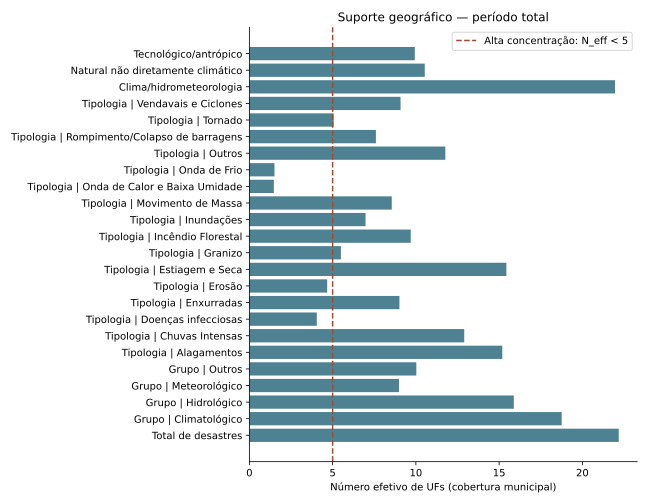

In [7]:
show('suporte',['periodo','exposicao','medida','eventos','uf_mes_positivos','ufs_expostas','n_eff','top1','top2','status'],n=40); show('suporte_design')
display(SVG(filename=str(FIG/'suporte_neff.svg')))

## 8. Estacionariedade em painel

CIPS/Pesaran via plm considera dependência comum. Lags1/2, drift/trend predefinidos; p tabulado tem limites0,01 e0,10. ΔI mantida; rejeição não confirma estacionariedade de todas UFs. ADF/KPSS complementares, Fisher não principal sob dependência.

In [8]:
show('cips',n=12); show('cips_exposicoes',n=16); show('adf_kpss_complementar')

,periodo,serie,deterministico,lags,CIPS,p,N,T
0,Total,taxa_inadimplencia,drift,1,-2.254054,0.028125,27,144
1,Total,taxa_inadimplencia,drift,2,-2.291687,0.017723,27,144
2,Total,taxa_inadimplencia,trend,1,-1.882181,0.100000,27,144
3,Total,taxa_inadimplencia,trend,2,-1.783215,0.100000,27,144
4,Total,delta,drift,1,-6.172200,0.010000,27,143
5,Total,delta,drift,2,-5.645215,0.010000,27,143
6,Pré,taxa_inadimplencia,drift,1,-2.148554,0.063257,27,85
7,Pré,taxa_inadimplencia,drift,2,-2.048473,0.100000,27,85
8,Pré,taxa_inadimplencia,trend,1,-2.354220,0.100000,27,85
9,Pré,taxa_inadimplencia,trend,2,-2.275085,0.100000,27,85


,periodo,serie,lags,CIPS,p,status
0,Total,total_desastres,1,NaN,NaN,não calculável: UF com série constante ou quas...
1,Total,total_desastres,2,NaN,NaN,não calculável: UF com série constante ou quas...
2,Total,grupo_climatologico,1,NaN,NaN,não calculável: UF com série constante ou quas...
3,Total,grupo_climatologico,2,NaN,NaN,não calculável: UF com série constante ou quas...
4,Total,grupo_hidrologico,1,NaN,NaN,não calculável: UF com série constante ou quas...
5,Total,grupo_hidrologico,2,NaN,NaN,não calculável: UF com série constante ou quas...
6,Total,grupo_meteorologico,1,NaN,NaN,não calculável: UF com série constante ou quas...
7,Total,grupo_meteorologico,2,NaN,NaN,não calculável: UF com série constante ou quas...
8,Pré,total_desastres,1,NaN,NaN,não calculável: UF com série constante ou quas...
9,Pré,total_desastres,2,NaN,NaN,não calculável: UF com série constante ou quas...


,periodo,serie,adf_rejeita_prop,adf_fisher_p,kpss_nao_rejeita_prop,concordancia_estacionaria_prop
0,Total (2013–2024),I em nível,0.407407,1.387732e-08,0.444444,0.222222
1,Total (2013–2024),I em nível após TWFE,0.148148,3.427240e-02,0.259259,0.000000
2,Total (2013–2024),ΔI,0.888889,3.364075e-150,0.962963,0.851852
3,Pré-pandemia (até jan/2020),I em nível,0.074074,1.517685e-04,0.222222,0.074074
4,Pré-pandemia (até jan/2020),I em nível após TWFE,0.148148,2.499855e-02,0.444444,0.074074
5,Pré-pandemia (até jan/2020),ΔI,0.629630,2.896629e-195,0.851852,0.518519


## 9. Nova especificação DLM

ΔI_it=α_i+λ_t+Σβ_k X_i,t−k+ε_it, X=cobertura0–1. Perfil de um pulso isolado; associação relativa UF-mês, não causalidade. FE mês-ano removem toda variação nacional comum.

In [9]:
show('principais',['periodo','exposicao','N','UFs','K','J','acumulado_cluster_estimate','acumulado_cluster_p','acumulado_boot_p'])

,periodo,exposicao,N,UFs,K,J,acumulado_cluster_estimate,acumulado_cluster_p,acumulado_boot_p
0,Total,Total de desastres,3564,27,12,3,0.058290,3.144312e-01,0.3182
1,Total,Grupo | Climatológico,3564,27,12,3,0.084634,4.425078e-01,0.4610
2,Total,Grupo | Hidrológico,3564,27,12,3,-0.027486,8.153061e-01,0.8216
3,Total,Grupo | Meteorológico,3564,27,12,3,0.095801,5.626777e-01,0.5894
4,Total,Grupo | Outros,3564,27,12,3,0.065106,1.479387e-01,0.2322
5,Total,Tipologia | Alagamentos,3564,27,12,3,-0.118033,7.132968e-01,0.7176
6,Total,Tipologia | Chuvas Intensas,3564,27,12,3,-0.228572,1.042087e-01,0.1077
7,Total,Tipologia | Doenças infecciosas,3564,27,12,3,-0.004057,9.822667e-01,0.9692
8,Total,Tipologia | Enxurradas,3564,27,12,3,0.529013,1.926863e-01,0.2840
9,Total,Tipologia | Erosão,3564,27,12,3,0.074426,1.188579e-01,0.5680


## 10. Horizonte comum K12

Cada exposição possui perfil próprio dentro da janela0–12. Horizonte máximo não é duração efetiva. Para comparabilidade, a amostra é comum aos candidatosJ e irrestritosK3/K6.

In [10]:
assert tables('principais').K.eq(12).all(); display(tables('principais').groupby('periodo').N.agg(['min','max']))

,min,max
periodo,,
Pré,1971,1971
Total,3564,3564


## 11. Smooth distributed lag

B natural cúbica, J3/4; Z=L B. β=Bθ; Vβ=B Vθ B′. J escolhido por BIC com N idêntico, sem p. Inferência condicional não incorpora incerteza de seleção; J alternativo permanece na multiverse.

In [11]:
B=basis(12,3); display(pd.DataFrame(B,index=range(13),columns=['B0','B1','B2'])); show('spline_candidatos')

,B0,B1,B2
0,1.000000,0.000000,0.000000
1,0.792824,0.247685,-0.040509
2,0.592593,0.481481,-0.074074
3,0.406250,0.687500,-0.093750
4,0.240741,0.851852,-0.092593
5,0.103009,0.960648,-0.063657
6,0.000000,1.000000,0.000000
7,-0.063657,0.960648,0.103009
8,-0.092593,0.851852,0.240741
9,-0.093750,0.687500,0.406250


,periodo,coluna,J,AIC,BIC,N
0,Total,total_desastres,3,-16179.287762,-15184.526917,3564
1,Total,total_desastres,4,-16177.295070,-15176.355587,3564
2,Total,grupo_climatologico,3,-16173.232804,-15178.471959,3564
3,Total,grupo_climatologico,4,-16171.262479,-15170.322995,3564
4,Total,grupo_hidrologico,3,-16176.358745,-15181.597900,3564
5,Total,grupo_hidrologico,4,-16174.781842,-15173.842358,3564
6,Total,grupo_meteorologico,3,-16172.479924,-15177.719079,3564
7,Total,grupo_meteorologico,4,-16170.758855,-15169.819371,3564
8,Total,grupo_outros,3,-16170.358970,-15175.598125,3564
9,Total,grupo_outros,4,-16168.692799,-15167.753316,3564


## 12. Perfis por grupo

Modelos separados, não todas exposições simultaneamente. Relatar acumulado, perfil conjunto e inferência, sem reduzir conclusão ao menor p.

,periodo,exposicao,acumulado_cluster_estimate,q_global_acumulado_cluster_p,q_global_acumulado_boot_p
1,Total,Grupo | Climatológico,0.084634,0.844017,0.906442
2,Total,Grupo | Hidrológico,-0.027486,0.931778,0.961873
3,Total,Grupo | Meteorológico,0.095801,0.844017,0.906442
4,Total,Grupo | Outros,0.065106,0.667914,0.906442
25,Pré,Grupo | Climatológico,-0.235715,0.389658,0.906442
26,Pré,Grupo | Hidrológico,0.101882,0.861155,0.906442
27,Pré,Grupo | Meteorológico,0.103315,0.722454,0.906442
28,Pré,Grupo | Outros,-0.186329,0.844017,0.906442


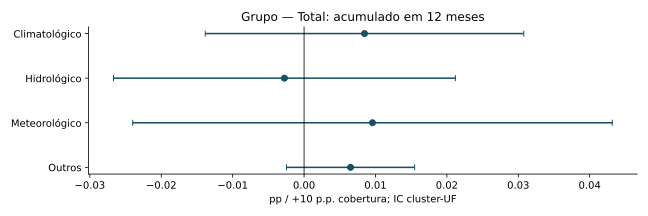

In [12]:
display(tables('principais').query("nivel=='Grupo'")[[ 'periodo','exposicao','acumulado_cluster_estimate','q_global_acumulado_cluster_p','q_global_acumulado_boot_p']])
display(SVG(filename=str(FIG/'forest_Total_Grupo.svg')))

## 13. Perfis por tipologia

A classificação administrativa completa continua disponível, incluindo doenças, Outros e barragens. Inelegíveis permanecem nas famílias planejadas.

,periodo,exposicao,suporte,acumulado_cluster_estimate,q_global_acumulado_boot_p
5,Total,Tipologia | Alagamentos,estimável,-0.118033,0.906442
6,Total,Tipologia | Chuvas Intensas,estimável,-0.228572,0.906442
7,Total,Tipologia | Doenças infecciosas,exposição altamente concentrada,-0.004057,1.000000
8,Total,Tipologia | Enxurradas,estimável com ressalvas,0.529013,0.906442
9,Total,Tipologia | Erosão,exposição altamente concentrada,0.074426,0.906442
10,Total,Tipologia | Estiagem e Seca,estimável,0.073356,0.906442
11,Total,Tipologia | Granizo,estimável com ressalvas,-0.510787,0.906442
12,Total,Tipologia | Incêndio Florestal,estimável com ressalvas,0.005586,1.000000
13,Total,Tipologia | Inundações,estimável com ressalvas,0.368403,0.906442
14,Total,Tipologia | Movimento de Massa,estimável com ressalvas,-1.887740,0.906442


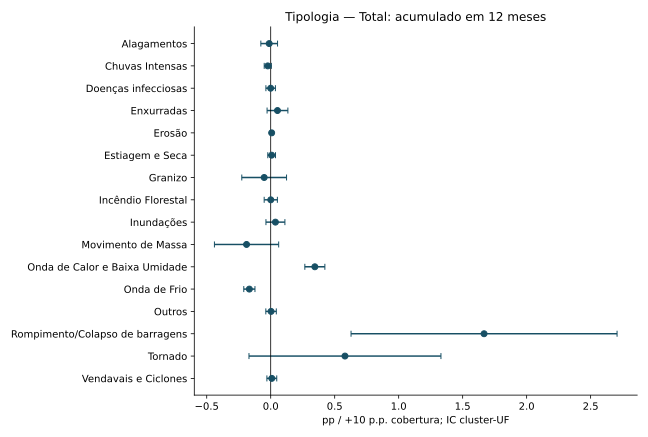

In [13]:
display(tables('principais').query("nivel=='Tipologia'")[[ 'periodo','exposicao','suporte','acumulado_cluster_estimate','q_global_acumulado_boot_p']])
display(SVG(filename=str(FIG/'forest_Total_Tipologia.svg')))

## 14. Horizontes específicos por mecanismo

Súbitos K6, com K3 irrestrito; persistentes K12 eK6; ambíguos/grupos K12. Mecanismo definido previamente, não por significância.

In [14]:
display(tables('multiverse').query("especificacao=='Mecanismo K6'")[[ 'periodo','exposicao','K','acumulado_cluster_estimate','acumulado_cluster_p']])

,periodo,exposicao,K,acumulado_cluster_estimate,acumulado_cluster_p
66,Total,Tipologia | Alagamentos,6,-0.252996,0.435235
100,Total,Tipologia | Enxurradas,6,0.356014,0.242846
123,Total,Tipologia | Estiagem e Seca,6,0.052605,0.542794
135,Total,Tipologia | Granizo,6,-0.214559,0.733365
147,Total,Tipologia | Incêndio Florestal,6,0.087055,0.576596
159,Total,Tipologia | Inundações,6,0.036613,0.773766
171,Total,Tipologia | Movimento de Massa,6,-1.130568,0.039770
183,Total,Tipologia | Onda de Calor e Baixa Umidade,6,2.003271,0.062745
228,Total,Tipologia | Tornado,6,4.068033,0.153140
240,Total,Tipologia | Vendavais e Ciclones,6,0.037909,0.798583


## 15. Curvas acumuladas e bandas

C(h)=Σ0..hβ. Toda covariância entra no SE. Bandas t multivariadas max-|t| aproximadas, condicionais à inferência cluster eJ; não corrigidas entre exposições. Para categorias concentradas, interpretar com CR2/WCR.

,periodo,exposicao,tipo_perfil,lag,estimate,se,low,high,sim_low,sim_high
0,Total,Total de desastres,beta,0,0.028358,0.009641,0.008541,0.048175,0.002411,0.054306
1,Total,Total de desastres,beta,1,0.020409,0.008523,0.002890,0.037929,-0.002530,0.043349
2,Total,Total de desastres,beta,2,0.012823,0.007644,-0.002889,0.028535,-0.007750,0.033396
3,Total,Total de desastres,beta,3,0.005962,0.007012,-0.008452,0.020376,-0.012912,0.024835
4,Total,Total de desastres,beta,4,0.000188,0.006569,-0.013314,0.013690,-0.017491,0.017867
5,Total,Total de desastres,beta,5,-0.004135,0.006198,-0.016875,0.008605,-0.020816,0.012546
6,Total,Total de desastres,beta,6,-0.006645,0.005775,-0.018516,0.005226,-0.022188,0.008898
7,Total,Total de desastres,beta,7,-0.007100,0.005250,-0.017891,0.003691,-0.021229,0.007029
8,Total,Total de desastres,beta,8,-0.005743,0.004775,-0.015559,0.004073,-0.018595,0.007109
9,Total,Total de desastres,beta,9,-0.002935,0.004663,-0.012520,0.006650,-0.015485,0.009615


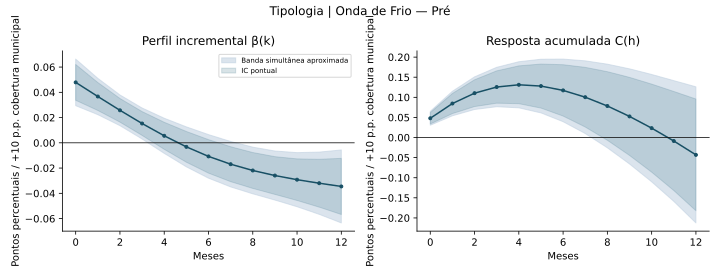

In [15]:
show('perfis',['periodo','exposicao','tipo_perfil','lag','estimate','se','low','high','sim_low','sim_high'],n=26)
rr=tables('principais'); ix=rr.index[(rr.coluna=='tipo_onda_de_frio')&(rr.periodo=='Pré')][0]
display(SVG(filename=str(FIG/f'pre_{ix}.svg')))

## 16. Leads/placebo

t+1,t+2,t+3 são incluídos além do perfil. Teste conjunto para diagnóstico; não são resultados substantivos. Falha inferencial HTZ fica indisponível; não rejeição não certifica exogeneidade.

In [16]:
show('placebos',['periodo','exposicao','joint_cluster_p','joint_boot_p','q_global_joint_boot_p'],n=46)

,periodo,exposicao,joint_cluster_p,joint_boot_p,q_global_joint_boot_p
0,Total,Total de desastres,6.544400e-01,0.7238,0.868560
1,Total,Grupo | Climatológico,3.452212e-01,0.4664,0.699600
2,Total,Grupo | Hidrológico,4.230294e-01,0.4108,0.688320
3,Total,Grupo | Meteorológico,2.361756e-02,0.1882,0.550232
4,Total,Grupo | Outros,8.857874e-02,0.3742,0.688320
5,Total,Tipologia | Alagamentos,1.407746e-01,0.6174,0.824043
6,Total,Tipologia | Chuvas Intensas,7.947333e-02,0.1136,0.550232
7,Total,Tipologia | Doenças infecciosas,5.244652e-09,0.1770,0.550232
8,Total,Tipologia | Enxurradas,7.347333e-01,0.7766,0.872557
9,Total,Tipologia | Erosão,1.810263e-02,0.4282,0.688320


## 17. Contemporâneo versus somente defasado

β0 não prova precedência. Somarβ1..12 do principal difere de refazer modelo semk0; ambos estão reportados.

In [17]:
display(tables('multiverse').query("especificacao=='Somente defasado'")[[ 'periodo','exposicao','acumulado_cluster_estimate','acumulado_boot_p']])

,periodo,exposicao,acumulado_cluster_estimate,acumulado_boot_p
7,Total,Total de desastres,0.037190,0.5050
18,Total,Grupo | Climatológico,0.073490,0.4928
29,Total,Grupo | Hidrológico,-0.047830,0.6650
40,Total,Grupo | Meteorológico,0.009095,0.9644
51,Total,Grupo | Outros,0.026151,0.5800
62,Total,Tipologia | Alagamentos,-0.204440,0.5526
74,Total,Tipologia | Chuvas Intensas,-0.260200,0.0575
85,Total,Tipologia | Doenças infecciosas,-0.114863,0.5716
96,Total,Tipologia | Enxurradas,0.446271,0.2868
108,Total,Tipologia | Erosão,0.063991,0.6272


## 18. Inferência cluster-UF

CR1S com t/F(G−1),27 clusters nominais. Contribuição desigual implica queG não resume suporte; aproximação pode ser otimista.

In [18]:
show('principais',['periodo','exposicao','acumulado_cluster_se','acumulado_cluster_p','joint_cluster_p'])

,periodo,exposicao,acumulado_cluster_se,acumulado_cluster_p,joint_cluster_p
0,Total,Total de desastres,0.056823,3.144312e-01,5.177687e-04
1,Total,Grupo | Climatológico,0.108523,4.425078e-01,4.166544e-01
2,Total,Grupo | Hidrológico,0.116482,8.153061e-01,2.667474e-01
3,Total,Grupo | Meteorológico,0.163377,5.626777e-01,8.556408e-03
4,Total,Grupo | Outros,0.043660,1.479387e-01,3.060774e-02
5,Total,Tipologia | Alagamentos,0.317744,7.132968e-01,1.232534e-01
6,Total,Tipologia | Chuvas Intensas,0.135755,1.042087e-01,2.407495e-01
7,Total,Tipologia | Doenças infecciosas,0.180788,9.822667e-01,9.182673e-02
8,Total,Tipologia | Enxurradas,0.395563,1.926863e-01,3.522439e-01
9,Total,Tipologia | Erosão,0.046147,1.188579e-01,2.924481e-01


## 19. CR2/Satterthwaite

clubSandwich validado com FE explícitos e igualdade dos coeficientes Python/R. Satterthwaite para contrastes; HTZ conjunto. df não positivo torna HTZ indisponível, sem fórmula improvisada.

In [19]:
show('cr2',['periodo','exposicao','design','endpoint','estimate','se','df','p','status_inferencia'],n=30)

,periodo,exposicao,design,endpoint,estimate,se,df,p,status_inferencia
0,Pré,Tipologia | Onda de Frio,coldtrace,acumulado,0.021103,0.034151,1.548850,0.615020,calculado
1,Pré,Tipologia | Onda de Frio,coldtrace,defasado,0.003973,0.034709,1.447822,0.922674,calculado
2,Pré,Tipologia | Onda de Frio,coldtrace,contemporaneo,0.017130,0.004554,1.321773,0.116459,calculado
3,Pré,Tipologia | Onda de Frio,coldtrace,joint,NaN,NaN,NaN,NaN,não disponível / suporte insuficiente para apr...
4,Pré,Tipologia | Onda de Frio,coldtrace,acumulado,0.047964,0.016453,1.345935,0.155921,calculado
5,Pré,Tipologia | Onda de Frio,coldtrace,defasado,0.021825,0.014029,1.481670,0.300035,calculado
6,Pré,Tipologia | Onda de Frio,coldtrace,contemporaneo,0.026139,0.017452,1.632307,0.298739,calculado
7,Pré,Tipologia | Onda de Frio,coldtrace,joint,NaN,NaN,NaN,NaN,não disponível / suporte insuficiente para apr...
8,Total,Tipologia | Onda de Frio,coldtrace,acumulado,-0.065653,0.026263,2.700587,0.097076,calculado
9,Total,Tipologia | Onda de Frio,coldtrace,defasado,-0.074215,0.030071,2.638728,0.101851,calculado


## 20. Wild cluster bootstrap

WCR11 null-imposed,4999/9999, pesos Rademacher UF; reabsorção de FE nas perturbações. Algoritmo de estatísticas suficientes conferido contra reestimação direta. P e erroMonteCarlo reportados. Poucas UFs informativas seguem sendo limitação.

In [20]:
show('principais',['periodo','exposicao','boot_B','acumulado_boot_p','acumulado_boot_mcse','joint_boot_p','joint_boot_mcse'],n=46)

,periodo,exposicao,boot_B,acumulado_boot_p,acumulado_boot_mcse,joint_boot_p,joint_boot_mcse
0,Total,Total de desastres,4999,0.3182,0.006587,0.0062,0.001110
1,Total,Grupo | Climatológico,4999,0.4610,0.007050,0.5354,0.007053
2,Total,Grupo | Hidrológico,4999,0.8216,0.005414,0.4472,0.007032
3,Total,Grupo | Meteorológico,4999,0.5894,0.006957,0.0738,0.003697
4,Total,Grupo | Outros,4999,0.2322,0.005971,0.2394,0.006035
5,Total,Tipologia | Alagamentos,9999,0.7176,0.004502,0.2347,0.004238
6,Total,Tipologia | Chuvas Intensas,9999,0.1077,0.003100,0.3897,0.004877
7,Total,Tipologia | Doenças infecciosas,4999,0.9692,0.002443,0.6478,0.006755
8,Total,Tipologia | Enxurradas,4999,0.2840,0.006377,0.4996,0.007071
9,Total,Tipologia | Erosão,4999,0.5680,0.007005,0.9380,0.003410


## 21. Driscoll–Kraay

DK Bartlett12; distância de calendário preservada após excluir pandemia. t(T−1) aproximado. Não escolher covariância pelo menor p.

In [21]:
show('principais',['periodo','exposicao','acumulado_dk_p','joint_dk_p'],n=46)

,periodo,exposicao,acumulado_dk_p,joint_dk_p
0,Total,Total de desastres,0.354340,3.177498e-03
1,Total,Grupo | Climatológico,0.498211,7.292691e-02
2,Total,Grupo | Hidrológico,0.753883,2.035936e-01
3,Total,Grupo | Meteorológico,0.538899,7.555903e-03
4,Total,Grupo | Outros,0.438516,2.210998e-01
5,Total,Tipologia | Alagamentos,0.738391,2.179809e-01
6,Total,Tipologia | Chuvas Intensas,0.083123,4.063168e-02
7,Total,Tipologia | Doenças infecciosas,0.985544,7.303682e-03
8,Total,Tipologia | Enxurradas,0.119681,2.429222e-02
9,Total,Tipologia | Erosão,0.080188,2.538713e-02


## 22. Dependência transversal e temporal

CD aproximado é afetado por restrições dos FE; correlações lag1/12 e teste auxiliar lag1 cluster. Ausência de rejeição não prova validade ou exogeneidade.

In [22]:
show('diagnosticos',n=46)

,periodo,coluna,exposicao,nivel,J,cd_stat,cd_p,correlacao_transversal_media,rho1,rho12,autocorr_cluster_p,hetero_corr
0,Total,total_desastres,Total de desastres,Total,3,-0.954906,0.339625,-0.004436,0.087104,0.115870,0.183674,0.002035
1,Total,grupo_climatologico,Grupo | Climatológico,Grupo,3,-0.995436,0.319524,-0.004625,0.088151,0.117004,0.175235,0.004309
2,Total,grupo_hidrologico,Grupo | Hidrológico,Grupo,3,-0.945694,0.344305,-0.004393,0.088613,0.115968,0.186348,-0.045121
3,Total,grupo_meteorologico,Grupo | Meteorológico,Grupo,3,-0.920449,0.357338,-0.004276,0.088587,0.116467,0.177324,-0.064389
4,Total,grupo_outros,Grupo | Outros,Grupo,3,-0.978990,0.327585,-0.004548,0.089533,0.116732,0.175159,-0.032137
5,Total,tipo_alagamentos,Tipologia | Alagamentos,Tipologia,3,-1.002510,0.316097,-0.004657,0.088058,0.117857,0.189410,-0.031300
6,Total,tipo_chuvas_intensas,Tipologia | Chuvas Intensas,Tipologia,3,-0.998042,0.318259,-0.004637,0.088300,0.117087,0.185835,-0.053139
7,Total,tipo_doencas_infecciosas,Tipologia | Doenças infecciosas,Tipologia,3,-1.004572,0.315103,-0.004667,0.088548,0.116654,0.181781,-0.027245
8,Total,tipo_enxurradas,Tipologia | Enxurradas,Tipologia,3,-0.990447,0.321955,-0.004601,0.089406,0.116280,0.176058,-0.060159
9,Total,tipo_erosao,Tipologia | Erosão,Tipologia,3,-0.929844,0.352452,-0.004320,0.089506,0.116839,0.174728,-0.044760


## 23. Pré versus pós

Pós=fev/2020; interação com data da resposta, respeitando préatéjan2020. Testarγ diretamente, não comparar p de recortes sobrepostos. Pré β, pósβ+γ, diferençaγ com covariância completa.

,exposicao,pre_cluster_estimate,pos_cluster_estimate,diferenca_cluster_estimate,acumulado_boot_p,joint_boot_p,q_global_joint_boot_p
0,Total de desastres,0.021890,0.069949,0.048060,0.5422,0.9020,0.941217
1,Grupo | Climatológico,-0.000492,0.122114,0.122607,0.4918,0.7666,0.927360
2,Grupo | Hidrológico,-0.023805,-0.030290,-0.006486,0.9700,0.7178,0.927360
3,Grupo | Meteorológico,0.159783,0.003817,-0.155966,0.5150,0.5166,0.927360
4,Grupo | Outros,-0.166201,0.084883,0.251085,0.5918,0.2106,0.927360
5,Tipologia | Alagamentos,-1.416943,0.030377,1.447320,0.4108,0.8693,0.941217
6,Tipologia | Chuvas Intensas,-0.389345,-0.201869,0.187476,0.4416,0.8818,0.941217
7,Tipologia | Doenças infecciosas,-0.112975,9.130886,9.243861,0.0930,0.2044,0.927360
8,Tipologia | Enxurradas,0.545483,0.320207,-0.225276,0.5546,0.3528,0.927360
9,Tipologia | Erosão,-2.237205,0.095028,2.332233,0.0054,0.0274,0.657600


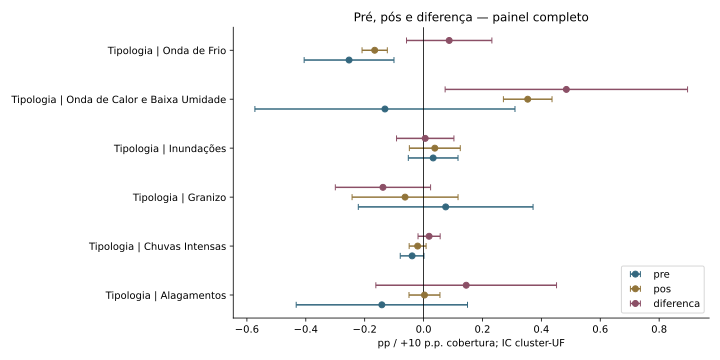

In [23]:
show('interacao',['exposicao','pre_cluster_estimate','pos_cluster_estimate','diferenca_cluster_estimate','acumulado_boot_p','joint_boot_p','q_global_joint_boot_p'],n=24)
display(SVG(filename=str(FIG/'pre_pos.svg')))

## 24. Robustez pandemia

Excluir respostasmar2020–dez2021, sem comprimir calendário dos lags. Respostas2022 ainda podem conter exposições pandêmicas; não é período totalmente livre de pandemia.

In [24]:
display(tables('multiverse').query("especificacao=='Exclui mar2020-dez2021'")[[ 'exposicao','N','acumulado_cluster_estimate','acumulado_cluster_p']])

,exposicao,N,acumulado_cluster_estimate,acumulado_cluster_p
10,Total de desastres,2970,0.069887,0.310738
21,Grupo | Climatológico,2970,0.094670,0.480920
32,Grupo | Hidrológico,2970,-0.026034,0.851491
43,Grupo | Meteorológico,2970,0.088627,0.547652
54,Grupo | Outros,2970,0.248221,0.028757
65,Tipologia | Alagamentos,2970,-1.057975,0.282264
77,Tipologia | Chuvas Intensas,2970,-0.228226,0.108947
88,Tipologia | Doenças infecciosas,2970,-0.068982,0.790577
99,Tipologia | Enxurradas,2970,0.571992,0.151029
111,Tipologia | Erosão,2970,-0.210205,0.807922


## 25. Efeitos fixos regionais

UF+Região×mês-ano absorve choques específicos das5regiões; rank conferido. O estimando depende de diferenças entre UFs da mesma região/mês.

In [25]:
display(tables('multiverse').query("especificacao=='Região × tempo'")[[ 'periodo','exposicao','rank','condition','acumulado_cluster_estimate']])

,periodo,exposicao,rank,condition,acumulado_cluster_estimate
8,Total,Total de desastres,3,1.702576,-0.002715
19,Total,Grupo | Climatológico,3,1.551633,-0.095534
30,Total,Grupo | Hidrológico,3,1.843193,0.054308
41,Total,Grupo | Meteorológico,3,2.055656,0.014312
52,Total,Grupo | Outros,3,2.094804,0.265139
63,Total,Tipologia | Alagamentos,3,1.843638,0.455949
75,Total,Tipologia | Chuvas Intensas,3,2.108503,-0.291849
86,Total,Tipologia | Doenças infecciosas,3,1.867503,0.274049
97,Total,Tipologia | Enxurradas,3,1.968276,0.433515
109,Total,Tipologia | Erosão,3,2.275271,0.298211


## 26. Estimando ponderado

Peso fixo participação da carteira médiaUF2013. Aproxima associação orientada ao sistema de crédito, diferente da UF média. Pesos não contemporâneos e não escolhidos por resultado.

In [26]:
show('pesos_credito',n=27); display(tables('multiverse').query("especificacao=='Ponderado CA2013'")[[ 'periodo','exposicao','acumulado_cluster_estimate','acumulado_cluster_p']])

,uf,peso_fixo_2013
0,AC,0.002517
1,AL,0.009333
2,AM,0.009050
3,AP,0.002562
4,BA,0.040740
5,CE,0.021110
6,DF,0.032269
7,ES,0.018338
8,GO,0.041809
9,MA,0.015385


,periodo,exposicao,acumulado_cluster_estimate,acumulado_cluster_p
9,Total,Total de desastres,0.033444,0.447881
20,Total,Grupo | Climatológico,-0.004098,0.967773
31,Total,Grupo | Hidrológico,0.026514,0.782585
42,Total,Grupo | Meteorológico,0.205620,0.187112
53,Total,Grupo | Outros,0.072812,0.188277
64,Total,Tipologia | Alagamentos,0.248092,0.054967
76,Total,Tipologia | Chuvas Intensas,-0.048766,0.724212
87,Total,Tipologia | Doenças infecciosas,-0.090435,0.460903
98,Total,Tipologia | Enxurradas,0.474947,0.314937
110,Total,Tipologia | Erosão,0.098556,0.035912


## 27. Decomposição da taxa

Auxiliares ΔlogCI eΔlogCA apenas categoriascentrais definidas antes. Crescimentos nominais, não corrigidos por inflação; interpretação sem nova família de descobertas.

In [27]:
show('decomposicao',['periodo','exposicao','target','acumulado_cluster_estimate','acumulado_cluster_p'])

,periodo,exposicao,target,acumulado_cluster_estimate,acumulado_cluster_p
0,Total,Tipologia | Alagamentos,carteira_inadimplencia_total,-0.011068,9.115069e-01
1,Total,Tipologia | Alagamentos,carteira_ativa_total,-0.009930,4.619452e-01
2,Total,Tipologia | Chuvas Intensas,carteira_inadimplencia_total,-0.093525,3.898872e-02
3,Total,Tipologia | Chuvas Intensas,carteira_ativa_total,0.014501,1.052668e-01
4,Total,Tipologia | Granizo,carteira_inadimplencia_total,0.018587,9.390852e-01
5,Total,Tipologia | Granizo,carteira_ativa_total,0.047695,5.160909e-01
6,Total,Tipologia | Inundações,carteira_inadimplencia_total,0.093046,5.082153e-02
7,Total,Tipologia | Inundações,carteira_ativa_total,0.042368,2.610667e-04
8,Total,Tipologia | Onda de Calor e Baixa Umidade,carteira_inadimplencia_total,0.661301,9.840405e-02
9,Total,Tipologia | Onda de Calor e Baixa Umidade,carteira_ativa_total,-0.213168,4.295585e-03


## 28. DLM nacional complementar

Taxa100ΣCI/ΣCA; cobertura nacionalΣmunicípios/5570; ΔI, sazonalidade, tendência, lagspróprios0/1/2 BIC, HAC12. Somaβ direta não é multiplicador total se houver dinâmica própria. Resposta recursiva sem bandas é exploratória.

In [28]:
show('nacional',['periodo','exposicao','N','p_proprio','acumulado_direto','q_global_p_acumulado','ljungbox12_p'],n=48)

,periodo,exposicao,N,p_proprio,acumulado_direto,q_global_p_acumulado,ljungbox12_p
0,Total,Total de desastres,132,1,0.070439,0.995853,0.600464
1,Total,Grupo | Climatológico,132,1,-0.588927,0.884653,0.646660
2,Total,Grupo | Hidrológico,132,1,0.586225,0.884653,0.533854
3,Total,Grupo | Meteorológico,132,1,-6.860757,0.376924,0.722888
4,Total,Grupo | Outros,132,1,-5.962629,0.897162,0.498622
5,Total,Tipologia | Alagamentos,132,1,19.690433,0.220118,0.502430
6,Total,Tipologia | Chuvas Intensas,132,1,0.260794,0.958211,0.502500
7,Total,Tipologia | Doenças infecciosas,132,1,-7.674245,0.767078,0.532316
8,Total,Tipologia | Enxurradas,132,1,-3.357874,0.884653,0.558237
9,Total,Tipologia | Erosão,132,1,14.748642,0.884653,0.493923


## 29. Multiplicidade

BH global48 separados para acumulado/perfil e inferência; placebo48; heterogeneidade24. Inelegíveisp=1 só no ajuste. BY e família local histórica visíveis. Não há correção hierárquica não demonstrada.

In [29]:
show('resumo_fdr'); print('Concordância ajustada nos4métodos:',len(summary()[1]))

Concordância ajustada nos4métodos: 0


,inferencia,acumulado,conjunto
0,cluster,3,15
1,boot,0,0
2,dk,2,12
3,cr2,0,0


## 30. Robustez/multiverse

Mudanças one-factor-at-a-time, sem todas combinações e sem selecionar por p. Medidas diferentes mudam unidade/estimando. Inferência sensível é reportada, não escolhida.

,periodo,exposicao,especificacao,medida,K,acumulado_cluster_estimate,acumulado_cluster_p,acumulado_dk_p
0,Total,Total de desastres,J alternativo,C_prop,12,0.058561,0.313179,0.355644
1,Total,Total de desastres,Exposição A,A,12,-0.004581,0.179222,0.210321
2,Total,Total de desastres,Exposição B,B,12,-0.004591,0.176363,0.210941
3,Total,Total de desastres,Exposição C,C,12,-0.003703,0.309040,0.398197
4,Total,Total de desastres,Irrestrito K3,C_prop,3,0.075135,0.047139,0.001243
5,Total,Total de desastres,Irrestrito K6,C_prop,6,0.043776,0.376399,0.167928
6,Total,Total de desastres,Almon K12 q2,C_prop,12,0.058415,0.314552,0.355167
7,Total,Total de desastres,Somente defasado,C_prop,12,0.037190,0.487094,0.536742
8,Total,Total de desastres,Região × tempo,C_prop,12,-0.002715,0.965637,0.957895
9,Total,Total de desastres,Ponderado CA2013,C_prop,12,0.033444,0.447881,0.319746


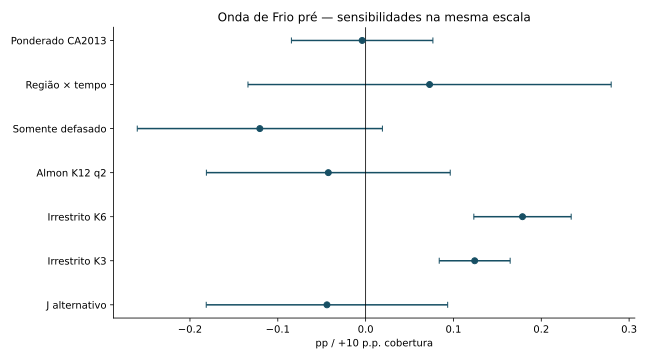

In [30]:
show('multiverse',['periodo','exposicao','especificacao','medida','K','acumulado_cluster_estimate','acumulado_cluster_p','acumulado_dk_p'],n=35)
display(SVG(filename=str(FIG/'onda_frio_robustez.svg')))

## 31. Onda de Frio: o resultado permanece?

Não robusto. MesmoA/K3 histórico reproduz soma, mas CR2/WCR perdem rejeição. Cobertura acentua concentraçãoMS. Retiradas dominantes podem ficar não estimáveis; não promover esses cenários.

In [31]:
display(tables('onda_frio_rastreio_A')[[ 'periodo','especificacao','acumulado_cluster_estimate','acumulado_cluster_p','acumulado_boot_p']]); display(tables('cr2').query("coluna=='tipo_onda_de_frio' and design in ['main','coldtrace']")[[ 'periodo','id','endpoint','estimate','df','p','status_inferencia']]); show('onda_frio_uf',n=54); show('onda_frio_leave_out',['periodo','retirada','status','n_eff','acumulado_cluster_estimate','acumulado_cluster_p'],n=56)

,periodo,especificacao,acumulado_cluster_estimate,acumulado_cluster_p,acumulado_boot_p
0,Total,Historico A K3,0.009014,0.626577,0.8760
1,Total,A smooth K12,-0.065653,0.006878,0.0244
2,Pré,Historico A K3,0.047964,0.000589,0.3461
3,Pré,A smooth K12,0.021103,0.475438,0.6020


,periodo,id,endpoint,estimate,df,p,status_inferencia
0,Pré,coldtrace_Pre_12,acumulado,0.021103,1.548850,0.615020,calculado
1,Pré,coldtrace_Pre_12,defasado,0.003973,1.447822,0.922674,calculado
2,Pré,coldtrace_Pre_12,contemporaneo,0.017130,1.321773,0.116459,calculado
3,Pré,coldtrace_Pre_12,joint,NaN,NaN,NaN,não disponível / suporte insuficiente para apr...
4,Pré,coldtrace_Pre_3,acumulado,0.047964,1.345935,0.155921,calculado
5,Pré,coldtrace_Pre_3,defasado,0.021825,1.481670,0.300035,calculado
6,Pré,coldtrace_Pre_3,contemporaneo,0.026139,1.632307,0.298739,calculado
7,Pré,coldtrace_Pre_3,joint,NaN,NaN,NaN,não disponível / suporte insuficiente para apr...
8,Total,coldtrace_Total_12,acumulado,-0.065653,2.700587,0.097076,calculado
9,Total,coldtrace_Total_12,defasado,-0.074215,2.638728,0.101851,calculado


,periodo,uf,registros,participacao
0,Total,AC,0,0.000000
1,Total,AL,0,0.000000
2,Total,AM,0,0.000000
3,Total,AP,0,0.000000
4,Total,BA,0,0.000000
5,Total,CE,0,0.000000
6,Total,DF,0,0.000000
7,Total,ES,3,0.014778
8,Total,GO,0,0.000000
9,Total,MA,1,0.004926


,periodo,retirada,status,n_eff,acumulado_cluster_estimate,acumulado_cluster_p
0,Total,AC,exposição altamente concentrada,1.508679,-1.702895,3.831701e-08
1,Total,AL,exposição altamente concentrada,1.508679,-1.603550,4.814674e-08
2,Total,AM,exposição altamente concentrada,1.508679,-1.641156,5.563580e-08
3,Total,AP,exposição altamente concentrada,1.508679,-1.656804,7.955433e-08
4,Total,BA,exposição altamente concentrada,1.508679,-1.640327,6.668305e-08
5,Total,CE,exposição altamente concentrada,1.508679,-1.620425,5.835986e-08
6,Total,DF,exposição altamente concentrada,1.508679,-1.668254,6.348846e-08
7,Total,ES,exposição altamente concentrada,1.457910,-1.704938,3.706591e-08
8,Total,GO,exposição altamente concentrada,1.508679,-1.720426,2.358070e-08
9,Total,MA,exposição altamente concentrada,1.499393,-1.663083,6.872625e-08


## 32. Granizo e tipologias com rejeições históricas

Não forçar concordância. O smoothDLM examina perfis e compensação; o conjunto pode rejeitar com soma≈0. Ausência de robustez inferencial limita formato/duração.

In [32]:
display(tables('principais').query("coluna=='tipo_granizo'")[[ 'periodo','acumulado_cluster_estimate','q_global_acumulado_boot_p','q_global_joint_boot_p']]); show('horizontes_descritivos',n=46)

,periodo,acumulado_cluster_estimate,q_global_acumulado_boot_p,q_global_joint_boot_p
11,Total,-0.510787,0.906442,0.351600
35,Pré,0.475354,0.961873,0.766629


,periodo,coluna,exposicao,h90_massa_absoluta,massa_0_2,massa_3_6,massa_7_12,formato_descritivo,classificacao_temporal,interpretacao
0,Total,total_desastres,Total de desastres,11,0.552851,0.151965,0.295184,compensação / reversão descritiva,inconclusivo: sem confirmação após FDR robusta,h90 não é duração de efeito; depende da spline...
1,Total,grupo_climatologico,Grupo | Climatológico,6,0.592425,0.338330,0.069245,compensação / reversão descritiva,inconclusivo: sem confirmação após FDR robusta,h90 não é duração de efeito; depende da spline...
2,Total,grupo_hidrologico,Grupo | Hidrológico,12,0.230786,0.336457,0.432757,compensação / reversão descritiva,inconclusivo: sem confirmação após FDR robusta,h90 não é duração de efeito; depende da spline...
3,Total,grupo_meteorologico,Grupo | Meteorológico,12,0.381400,0.200948,0.417652,compensação / reversão descritiva,inconclusivo: sem confirmação após FDR robusta,h90 não é duração de efeito; depende da spline...
4,Total,grupo_outros,Grupo | Outros,8,0.657716,0.192013,0.150271,compensação / reversão descritiva,inconclusivo: sem confirmação após FDR robusta,h90 não é duração de efeito; depende da spline...
5,Total,tipo_alagamentos,Tipologia | Alagamentos,12,0.210264,0.352019,0.437717,compensação / reversão descritiva,inconclusivo: sem confirmação após FDR robusta,h90 não é duração de efeito; depende da spline...
6,Total,tipo_chuvas_intensas,Tipologia | Chuvas Intensas,10,0.140158,0.379320,0.480521,compensação / reversão descritiva,inconclusivo: sem confirmação após FDR robusta,h90 não é duração de efeito; depende da spline...
7,Total,tipo_doencas_infecciosas,Tipologia | Doenças infecciosas,12,0.341024,0.155046,0.503931,compensação / reversão descritiva,inconclusivo: sem confirmação após FDR robusta,h90 não é duração de efeito; depende da spline...
8,Total,tipo_enxurradas,Tipologia | Enxurradas,12,0.496490,0.106657,0.396852,compensação / reversão descritiva,inconclusivo: sem confirmação após FDR robusta,h90 não é duração de efeito; depende da spline...
9,Total,tipo_erosao,Tipologia | Erosão,12,0.272327,0.069002,0.658671,compensação / reversão descritiva,inconclusivo: sem confirmação após FDR robusta,h90 não é duração de efeito; depende da spline...


## 33. Comparação com Granger

Somente recuperar etapa15. Granizo total exploratório, sensível àHAC/BIC; Onda deFrio não confirmado. Modelos nacionais transformados e painelTWFE têm perguntas e estimandos distintos.

In [33]:
display(Markdown((ROOT/'docs/granger_fechamento_resultados.md').read_text()))

# Fechamento de Granger — resultados executados

## Desenho e escopo

Protocolo publicado antes dos novos testes no commit f9396ee451421c2373b6e3f4badbd5ab0942bee9. Extensão exploratória informada05–14. Notebook15 executado integralmente: referência nacional,4 grupos e16 tipologias ×2 períodos. Fonte agregada SHA256 c613ebd61e25c05ebb4a4e0f3520c6570d673068d0b2ee2b6fc090468e1df679, correspondente ao checkpoint11. Nenhuma base bruta ou método seguinte reexecutado.

Principal fixa: Δ12ΔI; Δ12Δlog(1+D); intercepto; lags próprios1,2,3,12 e desastres1,2,3. Granger condicional na equação da inadimplência, não VAR/sistema. IC95% e teste conjunto HAC12, clássico/HC3 reportados. Três sensibilidades finitas: simples+dummies, relativa sazonal e sazonal BIC. Família principal42, sensibilidades126 e ajuste global168; nenhuma exclusão diagnóstica antes dos ajustes.

## Cobertura e amostras

Pré85 meses e total144 antes das transformações; amostras comuns finais60 e119, ambas fev/2015 até respectivos términos. Não foram usadas observações anteriores ao recorte para construir transformações ou lags. Principal: k8 e GL52/111. Dois cenários pré inelegíveis: Onda de Calor e Baixa Umidade(14 meses positivos,19 protocolos) e Rompimento/Colapso de barragens(6 meses positivos,15 protocolos). Permanecem na matriz e famílias; p original ausente,1 somente no ajuste. Total: todos21 estimados. Todos os nomes administrativos originais preservados; a tabela anterior permite categorias ambíguas/múltiplos grupos. **Códigos numéricos do Atlas não constam na entrada agregada validada; a base bruta ausente impede sua recuperação, sem afetar as contagens disponíveis.** A interpretação climática não transforma Outros/doenças/barragens em eventos climáticos.

| Família | Período | Planejados | Estimáveis | Nominais | BH | BY | Holm | Triagem básica | Ampliada |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Principal | Pré |21|19|8|5|1|1|0|0|
| Principal | Total |21|21|9|5|1|1|6|4|
| Sensibilidades | Pré |63|57|20|11|5|5|0|0|
| Sensibilidades | Total |63|63|22|9|1|1|37|20|

**Rejeições ajustadas não equivalem a resultados interpretáveis.** Todos os resultados pré continuam limitados por estacionariedade inconclusiva da inadimplência. No total, apenas Granizo combina BH e triagem ampliada na principal. Hidrológico, Chuvas Intensas e Vendavais/Ciclones passam essa triagem, mas só rejeitam nominalmente na principal. Triagem significa ausência de indicação pelos critérios examinados, não prova de adequação.

## Granizo: sinal novo, sensível à inferência

Principal total: p HAC=0,000268726; BH42=0,005643; BY42=0,024417; Holm42=0,011018. Também mantém ajuste global168(Holm≈0,04353). Soma dos coeficientes≈0,032262 pp por unidade de Δ12Δlog(1+D), IC95% pontual HAC[0,012810;0,051713]; não é resposta causal acumulada. A soma depende da forma do choque nas variáveis transformadas, não significa que um protocolo aumente I em0,032pp.

**Não persiste no clássico/HC3**(BH≈0,5306/0,4292) nem na seleção BIC(p≈0,1167; q0 preferido). A relativa sazonal conserva BH, mas não BY/Holm. Estabilidade geral principal p≈0,136 não rejeita; isso não comprova estabilidade. Portanto: sinal exploratório sensível à covariância e à especificação; não confirmação robusta, causal, nem validação de capacidade preditiva fora da amostra.

## Onda de Frio e histórico

Principal total: p≈0,01610; BH42≈0,05635, com autocorrelação curta e mudança pós-março2020(p≈0,002352). Não reúne ajuste e adequação. BIC sazonal reproduz exatamente p14≈0,002175706; BH nesta nova família126≈0,022845, BY≈0,12376 e Holm≈0,25021. Triagem ampliada favorável, mas q0 preferido e clássico/HC3 não sustentam ajuste. O BH histórico14≈0,03956 continua preservado; a diferença de BH decorre da família nova, não substitui o histórico.

Análise anterior05–09:235 testes distintos selecionados,29 nominais,0BH;18/29 com autocorrelação do sistema e4/29 passando triagem anterior. Etapa14:41 cenários nacionais com triagem básica favorável, apenas Onda de Frio tambémBH. Nesta etapa15 a ordem fixa, nova família e diagnóstico ampliado mudam o desenho: não comparar contagens de rejeição como medida direta de progresso. Estabilidade total na principal falha nominalmente em14/21; CUSUM pode não rejeitar simultaneamente. O teste anterior de interações(p≈0,00018) e o CUSUM(p≈0,639) continuam documentados; não foram removidos ou usados para selecionar data.

## Interpretação e encerramento

A revisão cobre todos os grupos/tipologias nos dois períodos. A evidência segue exploratória: os sinais ajustados pré têm inferência comprometida; no total Granizo satisfaz a triagem da principal HAC, mas depende da inferência/especificação. Outros sinais ajustados têm limitações ou seleção BIC e preferência por q0. Não há confirmação robusta e geral de desastres→inadimplência. Não rejeitar também não prova ausência de efeito.

Os recortes se sobrepõem; significância diferente não testa diferença de efeito entre períodos. Precedência condicional não identifica causalidade estrutural, e o teste conjunto não fornece sozinho sinal ou magnitude. Atlas é exposição retrospectiva por contagem, não gravidade única nem informação garantidamente disponível em tempo real. Não foram adicionados controles econômicos sem fonte/cobertura compatível. Podemos encerrar esta etapa e avançar para outro método com esse mapa de limitações preservado. Nenhum método seguinte executado.

## Reprodução, integridade e limitações materiais

Notebook15 reproduzido integralmente no ambiente registrado; a validação substantiva compara F restrito/Wald, ausencia de alvo contemporâneo, famílias, GL e reprodução dos p BIC sazonais14. Conferência de saídas históricas não é reprodução integral05–14 nem diagnóstico estatístico. Bases df_tcc_2013_2024.parquet e BD_Atlas_1991_2024_v1.0_2025.04.14_Consolidado.csv indisponíveis: impedem reconstrução da integração bruta, códigos e reprodução integral10–13, não a análise15 baseada em agregados hash-conferidos. Checkpoints antigos são snapshots e não serão relabelados como execução atual. Bootstrap/TY não adicionais: não corrigiriam automaticamente a instabilidade/autocorrelação/estacionariedade.

Fontes metodológicas primárias: [ADF](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html), [KPSS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html), [BG](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.acorr_breusch_godfrey.html), [RESET](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.linear_reset.html), [correções múltiplas](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html). HAC12 é sensibilidade/referência previamente registrada, com aproximações de pequena amostra; não garantia de tamanho correto em60 observações ou modelo mal especificado.


## 34. Conclusões e verificação

Nenhuma rejeição principalBH sobrevive emCR2/WCR. Não há classificação robusta de resposta curta/lenta; não equivale à ausência de impacto. Todos os testes de integridade/cálculos devem passar, sem exigir significância.

In [34]:
from verificar_dlm_revisao import verify
display(verify()); display(Markdown((ROOT/'docs/dlm_revisao_resultados.md').read_text()))
show('classificacao_final',n=46)

,verificacao,passou
0,Lags e leads: valores e limites por UF,True
1,Chave municipal preserva municípios e códigos ...,True
2,Atlas reconciliado em todas as células UF-mês,True
3,"Spline, reconstrução beta, covariância e C(h)",True
4,"Contrastes pré, pós e diferença",True
5,Pesos fixos e período-base,True
6,N_eff uniforme e concentrado,True
7,BH preserva família planejada,True
8,Absorção FE equivale a dummies explícitas,True
9,WCR11 rápido equivale a reestimação sob H0 com FE,True


# Revisão metodológica DLM — resultados



46 de 48 cenários estimados. Horizonte 0–12; cobertura municipal relativa; seleção J3/J4 por BIC. Resultados históricos preservados em dlm/. Protocolo prévio no commit 1641dfd. Nenhum Granger reestimado e nenhum SARIMAX executado.



## A. Problemas anteriores

K curto selecionado em DLM irrestrito não mede duração. Suporte esparso, 27 clusters nominais com contribuição desigual, ausência de placebos e comparação de recortes sobrepostos limitavam a interpretação. Os testes antigos exigiam o resultado de Onda de Frio; novos testes não exigem significância.



## B. Ajustes implementados

Auditoria UF-mês exata; ocorrências municipais auditáveis; cobertura; classificação por COBRADE; suporte e N_eff; splines; C(h); bandas condicionais; placebos; interação; inferência CR2/WCR/DK; multiverse finita; ponderação fixa; nacional complementar.



## C. Especificação principal

ΔI em pp; C_prop em escala 0–1; K12; spline natural J3/4; UF FE e mês-ano FE; não ponderado; CR1S, CR2+Satterthwaite/HTZ, WCR11 e DK12; BH global48 separado por endpoint/inferência. Não há seleção por p.



## D. Exposição

40339 registros; 40238 chaves municipais únicas; 101 repetições da chave; nenhuma duplicata exata. Cobertura significa municípios com registros, não população/área ou intensidade. Mudança +10 pp de cobertura multiplica coeficiente por 0,1. A/B/C são sensibilidades, com estimandos/unidades distintos. 13310 em Chuvas Intensas exige ressalva nome/código; 14140 não permite isolar onda de calor de baixa umidade.



## E. Defasagens por tipo

K12 compara janelas sem impor curvas iguais. Horizontes ex ante K6 para súbitos e robustez K6 para persistentes. A métrica h90 de massa absoluta é descritiva, não último lag significativo nem duração causal. Perfis sem suporte e estabilidade ficam inconclusivos.



## F. Resultados gerais

{"cluster": {"acumulado": 3, "conjunto": 15}, "boot": {"acumulado": 0, "conjunto": 0}, "dk": {"acumulado": 2, "conjunto": 12}, "cr2": {"acumulado": 0, "conjunto": 0}}



Rejeições BH global48 por inferência (acumulado/conjunto). Concordância nos quatro métodos é necessária, mas insuficiente para robustez substantiva.

Acumulados simultaneamente ajustados em todos os quatro: 0.



## G. Grupos e agregados analíticos

| periodo   | exposicao                         |   acumulado_cluster_estimate |   q_global_acumulado_cluster_p |   q_global_acumulado_boot_p |
|:----------|:----------------------------------|-----------------------------:|-------------------------------:|----------------------------:|
| Total     | Total de desastres                |                    0.0582895 |                       0.722454 |                    0.906442 |
| Total     | Grupo | Climatológico             |                    0.0846342 |                       0.844017 |                    0.906442 |
| Total     | Grupo | Hidrológico               |                   -0.0274861 |                       0.931778 |                    0.961873 |
| Total     | Grupo | Meteorológico             |                    0.0958008 |                       0.844017 |                    0.906442 |
| Total     | Grupo | Outros                    |                    0.0651063 |                       0.667914 |                    0.906442 |
| Total     | Clima/hidrometeorologia           |                    0.0610041 |                       0.802029 |                    0.906442 |
| Total     | Natural não diretamente climático |                    0.0455306 |                       0.760209 |                    0.906442 |
| Total     | Tecnológico/antrópico             |                   -0.0630849 |                       0.931778 |                    0.972726 |
| Pré       | Total de desastres                |                   -0.0738098 |                       0.722454 |                    0.906442 |
| Pré       | Grupo | Climatológico             |                   -0.235715  |                       0.389658 |                    0.906442 |
| Pré       | Grupo | Hidrológico               |                    0.101882  |                       0.861155 |                    0.906442 |
| Pré       | Grupo | Meteorológico             |                    0.103315  |                       0.722454 |                    0.906442 |
| Pré       | Grupo | Outros                    |                   -0.186329  |                       0.844017 |                    0.906442 |
| Pré       | Clima/hidrometeorologia           |                   -0.0862026 |                       0.722454 |                    0.906442 |
| Pré       | Natural não diretamente climático |                   -0.204057  |                       0.844017 |                    0.906442 |
| Pré       | Tecnológico/antrópico             |                    0.993817  |                       0.844017 |                    0.906442 |



## H. Tipologias

| periodo   | exposicao                                   |   acumulado_cluster_estimate |   q_global_acumulado_cluster_p |   q_global_acumulado_boot_p |   q_global_joint_boot_p |
|:----------|:--------------------------------------------|-----------------------------:|-------------------------------:|----------------------------:|------------------------:|
| Total     | Tipologia | Alagamentos                     |                  -0.118033   |                    0.877904    |                    0.906442 |                0.739657 |
| Total     | Tipologia | Chuvas Intensas                 |                  -0.228572   |                    0.667914    |                    0.906442 |                0.761856 |
| Total     | Tipologia | Doenças infecciosas             |                  -0.00405723 |                    1           |                    1        |                0.887481 |
| Total     | Tipologia | Enxurradas                      |                   0.529013   |                    0.667914    |                    0.906442 |                0.826924 |
| Total     | Tipologia | Erosão                          |                   0.074426   |                    0.667914    |                    0.906442 |                1        |
| Total     | Tipologia | Estiagem e Seca                 |                   0.0733559  |                    0.861155    |                    0.906442 |                1        |
| Total     | Tipologia | Granizo                         |                  -0.510787   |                    0.844017    |                    0.906442 |                0.3516   |
| Total     | Tipologia | Incêndio Florestal              |                   0.00558559 |                    1           |                    1        |                0.887481 |
| Total     | Tipologia | Inundações                      |                   0.368403   |                    0.722454    |                    0.906442 |                1        |
| Total     | Tipologia | Movimento de Massa              |                  -1.88774    |                    0.667914    |                    0.906442 |                0.3008   |
| Total     | Tipologia | Onda de Calor e Baixa Umidade   |                   3.44963    |                    7.6206e-08  |                    0.906442 |                0.739657 |
| Total     | Tipologia | Onda de Frio                    |                  -1.66771    |                    6.18376e-07 |                    0.906442 |                0.739657 |
| Total     | Tipologia | Outros                          |                   0.0278552  |                    0.97098     |                    0.999491 |                0.925538 |
| Total     | Tipologia | Rompimento/Colapso de barragens |                  16.6721     |                    0.0452599   |                    0.906442 |                0.545067 |
| Total     | Tipologia | Tornado                         |                   5.80248    |                    0.667914    |                    0.906442 |                0.887481 |
| Total     | Tipologia | Vendavais e Ciclones            |                   0.0869187  |                    0.861598    |                    0.906442 |                0.545067 |
| Pré       | Tipologia | Alagamentos                     |                  -1.66291    |                    0.823953    |                    0.906442 |                0.94884  |
| Pré       | Tipologia | Chuvas Intensas                 |                  -0.301363   |                    0.667914    |                    0.906442 |                1        |
| Pré       | Tipologia | Doenças infecciosas             |                  -0.136481   |                    0.861598    |                    0.906442 |                0.8859   |
| Pré       | Tipologia | Enxurradas                      |                   0.189717   |                    0.861155    |                    0.906442 |                0.875148 |
| Pré       | Tipologia | Erosão                          |                  -2.07095    |                    0.667914    |                    0.906442 |                0.60672  |
| Pré       | Tipologia | Estiagem e Seca                 |                  -0.25052    |                    0.545238    |                    0.906442 |                0.739657 |
| Pré       | Tipologia | Granizo                         |                   0.475354   |                    0.931778    |                    0.961873 |                0.766629 |
| Pré       | Tipologia | Incêndio Florestal              |                  -0.594424   |                    0.667914    |                    0.906442 |                0.766629 |
| Pré       | Tipologia | Inundações                      |                   0.97728    |                    0.667914    |                    0.906442 |                0.887481 |
| Pré       | Tipologia | Movimento de Massa              |                  -0.480768   |                    0.871176    |                    0.906442 |                0.739657 |
| Pré       | Tipologia | Onda de Frio                    |                  -0.431967   |                    0.844017    |                    0.906442 |                0.739657 |
| Pré       | Tipologia | Outros                          |                   0.166999   |                    0.97098     |                    0.972726 |                1        |
| Pré       | Tipologia | Tornado                         |                   5.05841    |                    0.722454    |                    0.960738 |                0.761856 |
| Pré       | Tipologia | Vendavais e Ciclones            |                   0.0611479  |                    0.844017    |                    0.906442 |                0.739657 |



## I. Onda de Frio

Total: C12=-1.66771 pp/unidade; cluster p=2.57657e-08; WCR p=0.2734; DK p=1.28583e-05; CR2 p=0.228893, df=1.099; N_eff cobertura=1.509; top1=80.6%; top2=91.3%.

Pré: C12=-0.431967 pp/unidade; cluster p=0.528295; WCR p=0.6535; DK p=0.633749; CR2 p=0.774389, df=1.128; N_eff cobertura=1.509; top1=79.8%; top2=95.8%.



**Classificação do sinal positivo pré anterior: não robusto.** A versão principal revisada não o reproduz; suporte fortemente concentrado. Não comparar magnitudes brutas C_prop e log1p(A). Rastreio A/K3 mostra o impacto isolado de ampliar inferência na medida histórica. As retiradas de UFs incluem cenários que perdem suporte mínimo e não devem ser promovidos a especificações principais.



| periodo   | retirada   | status                          |   n_eff |   acumulado_cluster_estimate |   acumulado_cluster_low |   acumulado_cluster_high |   acumulado_cluster_p |
|:----------|:-----------|:--------------------------------|--------:|-----------------------------:|------------------------:|-------------------------:|----------------------:|
| Total     | AC         | exposição altamente concentrada | 1.50868 |                  -1.70289    |               -2.1533   |                -1.25249  |           3.8317e-08  |
| Total     | AL         | exposição altamente concentrada | 1.50868 |                  -1.60355    |               -2.03312  |                -1.17398  |           4.81467e-08 |
| Total     | AM         | exposição altamente concentrada | 1.50868 |                  -1.64116    |               -2.08439  |                -1.19792  |           5.56358e-08 |
| Total     | AP         | exposição altamente concentrada | 1.50868 |                  -1.6568     |               -2.11342  |                -1.20019  |           7.95543e-08 |
| Total     | BA         | exposição altamente concentrada | 1.50868 |                  -1.64033    |               -2.08789  |                -1.19276  |           6.6683e-08  |
| Total     | CE         | exposição altamente concentrada | 1.50868 |                  -1.62042    |               -2.05924  |                -1.18161  |           5.83599e-08 |
| Total     | DF         | exposição altamente concentrada | 1.50868 |                  -1.66825    |               -2.12218  |                -1.21433  |           6.34885e-08 |
| Total     | ES         | exposição altamente concentrada | 1.45791 |                  -1.70494    |               -2.15505  |                -1.25483  |           3.70659e-08 |
| Total     | GO         | exposição altamente concentrada | 1.50868 |                  -1.72043    |               -2.16342  |                -1.27743  |           2.35807e-08 |
| Total     | MA         | exposição altamente concentrada | 1.49939 |                  -1.66308    |               -2.11763  |                -1.20853  |           6.87262e-08 |
| Total     | MG         | exposição altamente concentrada | 1.43289 |                  -1.6815     |               -2.11203  |                -1.25096  |           2.12704e-08 |
| Total     | MS         | exposição altamente concentrada | 2.89456 |                  -7.04554    |              -14.5173   |                 0.426209 |           0.0634783   |
| Total     | MT         | exposição altamente concentrada | 1.48033 |                  -1.71733    |               -2.13351  |                -1.30115  |           7.67148e-09 |
| Total     | PA         | exposição altamente concentrada | 1.50868 |                  -1.65958    |               -2.11517  |                -1.20399  |           7.42574e-08 |
| Total     | PB         | exposição altamente concentrada | 1.50868 |                  -1.62386    |               -2.06719  |                -1.18052  |           6.73857e-08 |
| Total     | PE         | exposição altamente concentrada | 1.50868 |                  -1.59359    |               -2.01288  |                -1.17431  |           3.4864e-08  |
| Total     | PI         | exposição altamente concentrada | 1.50868 |                  -1.6186     |               -2.05951  |                -1.17769  |           6.47649e-08 |
| Total     | PR         | exposição altamente concentrada | 1.49858 |                  -1.70305    |               -2.14391  |                -1.2622   |           2.597e-08   |
| Total     | RJ         | exposição altamente concentrada | 1.44448 |                  -1.64668    |               -2.11621  |                -1.17715  |           1.43644e-07 |
| Total     | RN         | exposição altamente concentrada | 1.50868 |                  -1.63702    |               -2.0831   |                -1.19094  |           6.5163e-08  |
| Total     | RO         | exposição altamente concentrada | 1.50868 |                  -1.71305    |               -2.16144  |                -1.26467  |           3.17511e-08 |
| Total     | RR         | exposição altamente concentrada | 1.50868 |                  -1.64295    |               -2.09697  |                -1.18892  |           8.34181e-08 |
| Total     | RS         | exposição altamente concentrada | 1.49653 |                  -1.70867    |               -2.15292  |                -1.26442  |           2.8121e-08  |
| Total     | SC         | exposição altamente concentrada | 1.2247  |                  -1.64991    |               -2.04233  |                -1.25749  |           5.38393e-09 |
| Total     | SE         | exposição altamente concentrada | 1.50868 |                  -1.641      |               -2.09107  |                -1.19093  |           7.30412e-08 |
| Total     | SP         | exposição altamente concentrada | 1.50242 |                  -1.68953    |               -2.13814  |                -1.24092  |           4.10877e-08 |
| Total     | TO         | exposição altamente concentrada | 1.50868 |                  -1.72861    |               -2.17079  |                -1.28643  |           2.09047e-08 |
| Total     | MS + SC    | exposição altamente concentrada | 4.80437 |                 -12.948      |              -42.1005   |                16.2045   |           0.368433    |
| Pré       | AC         | exposição altamente concentrada | 1.50875 |                  -0.483106   |               -1.90338  |                 0.93717  |           0.490052    |
| Pré       | AL         | exposição altamente concentrada | 1.50875 |                  -0.287219   |               -1.68973  |                 1.11529  |           0.676796    |
| Pré       | AM         | exposição altamente concentrada | 1.50875 |                  -0.557873   |               -2.01647  |                 0.900725 |           0.438268    |
| Pré       | AP         | exposição altamente concentrada | 1.50875 |                  -0.45526    |               -1.86782  |                 0.957303 |           0.512909    |
| Pré       | BA         | exposição altamente concentrada | 1.50875 |                  -0.476156   |               -1.92289  |                 0.970574 |           0.504095    |
| Pré       | CE         | exposição altamente concentrada | 1.50875 |                  -0.462745   |               -1.91804  |                 0.992545 |           0.518525    |
| Pré       | DF         | exposição altamente concentrada | 1.50875 |                  -0.427598   |               -1.86016  |                 1.00497  |           0.544282    |
| Pré       | ES         | exposição altamente concentrada | 1.42473 |                  -0.648794   |               -2.01551  |                 0.71792  |           0.337597    |
| Pré       | GO         | exposição altamente concentrada | 1.50875 |                  -0.466368   |               -1.90588  |                 0.973139 |           0.510728    |
| Pré       | MA         | exposição altamente concentrada | 1.50875 |                  -0.40898    |               -1.83295  |                 1.01499  |           0.559482    |
| Pré       | MG         | exposição altamente concentrada | 1.49293 |                  -0.504413   |               -1.94453  |                 0.935701 |           0.477374    |
| Pré       | MS         | exposição altamente concentrada | 1.54173 |                  10.3198     |               -2.9378   |                23.5773   |           0.121461    |
| Pré       | MT         | exposição altamente concentrada | 1.50875 |                  -0.548585   |               -2.01148  |                 0.91431  |           0.447162    |
| Pré       | PA         | exposição altamente concentrada | 1.50875 |                  -0.528218   |               -1.93158  |                 0.875145 |           0.445493    |
| Pré       | PB         | exposição altamente concentrada | 1.50875 |                  -0.370326   |               -1.77035  |                 1.0297   |           0.590734    |
| Pré       | PE         | exposição altamente concentrada | 1.50875 |                  -0.361779   |               -1.82206  |                 1.0985   |           0.614358    |
| Pré       | PI         | exposição altamente concentrada | 1.50875 |                  -0.254453   |               -1.62669  |                 1.11778  |           0.705763    |
| Pré       | PR         | exposição altamente concentrada | 1.50875 |                  -0.41146    |               -1.85324  |                 1.03032  |           0.561967    |
| Pré       | RJ         | exposição altamente concentrada | 1.50875 |                  -0.545715   |               -2.01165  |                 0.920215 |           0.450443    |
| Pré       | RN         | exposição altamente concentrada | 1.50875 |                  -0.44098    |               -1.9003   |                 1.01834  |           0.539344    |
| Pré       | RO         | exposição altamente concentrada | 1.50875 |                  -0.441704   |               -1.8362   |                 0.952796 |           0.520127    |
| Pré       | RR         | exposição altamente concentrada | 1.50875 |                   0.00409261 |               -0.968041 |                 0.976226 |           0.993151    |
| Pré       | RS         | exposição altamente concentrada | 1.49516 |                  -0.412596   |               -1.88355  |                 1.05836  |           0.56864     |
| Pré       | SC         | exposição altamente concentrada | 1.10692 |                  -0.589873   |               -2.10725  |                 0.927505 |           0.430886    |
| Pré       | SE         | exposição altamente concentrada | 1.50875 |                  -0.388279   |               -1.80737  |                 1.03081  |           0.578105    |
| Pré       | SP         | exposição altamente concentrada | 1.49827 |                  -0.430559   |               -1.88416  |                 1.02304  |           0.54734     |
| Pré       | TO         | exposição altamente concentrada | 1.50875 |                  -0.56484    |               -1.97433  |                 0.844655 |           0.416986    |
| Pré       | MS + SC    | não estimável                   | 1.98919 |                  -6.39077    |              -85.9852   |                73.2037   |           0.86977     |



## J. Placebos

Rejeições BH leads: cluster=15; WCR=0; CR2=0. Placebos não comprovam exogeneidade quando não rejeitam.



## K. Pré versus pós

| exposicao                                   |   pre_cluster_estimate |   pos_cluster_estimate |   diferenca_cluster_estimate |   q_global_joint_boot_p |
|:--------------------------------------------|-----------------------:|-----------------------:|-----------------------------:|------------------------:|
| Total de desastres                          |            0.0218897   |              0.0699492 |                   0.0480595  |                0.941217 |
| Grupo | Climatológico                       |           -0.000492208 |              0.122114  |                   0.122607   |                0.92736  |
| Grupo | Hidrológico                         |           -0.0238047   |             -0.0302903 |                  -0.00648555 |                0.92736  |
| Grupo | Meteorológico                       |            0.159783    |              0.0038167 |                  -0.155966   |                0.92736  |
| Grupo | Outros                              |           -0.166201    |              0.0848835 |                   0.251085   |                0.92736  |
| Tipologia | Alagamentos                     |           -1.41694     |              0.0303773 |                   1.44732    |                0.941217 |
| Tipologia | Chuvas Intensas                 |           -0.389345    |             -0.201869  |                   0.187476   |                0.941217 |
| Tipologia | Doenças infecciosas             |           -0.112975    |              9.13089   |                   9.24386    |                0.92736  |
| Tipologia | Enxurradas                      |            0.545483    |              0.320207  |                  -0.225276   |                0.92736  |
| Tipologia | Erosão                          |           -2.23721     |              0.095028  |                   2.33223    |                0.6576   |
| Tipologia | Estiagem e Seca                 |            0.0329989   |              0.10663   |                   0.0736313  |                0.92736  |
| Tipologia | Granizo                         |            0.750631    |             -0.62873   |                  -1.37936    |                0.92736  |
| Tipologia | Incêndio Florestal              |           -0.45142     |              0.0282354 |                   0.479655   |                0.92736  |
| Tipologia | Inundações                      |            0.325492    |              0.3816    |                   0.0561078  |                0.92736  |
| Tipologia | Movimento de Massa              |           -0.942933    |             -2.83416   |                  -1.89123    |                0.92736  |
| Tipologia | Onda de Calor e Baixa Umidade   |           -1.31204     |              3.5364    |                   4.84844    |                0.92736  |
| Tipologia | Onda de Frio                    |           -2.53031     |             -1.6604    |                   0.869914   |                0.92736  |
| Tipologia | Outros                          |            0.401659    |              0.0187675 |                  -0.382892   |                0.9642   |
| Tipologia | Rompimento/Colapso de barragens |           21.7072      |            -18.7547    |                 -40.4619     |                0.92736  |
| Tipologia | Tornado                         |            5.08615     |              7.43041   |                   2.34426    |                0.92736  |
| Tipologia | Vendavais e Ciclones            |            0.10577     |              0.0110391 |                  -0.0947311  |                0.92736  |
| Clima/hidrometeorologia                     |            0.0144219   |              0.0714972 |                   0.0570753  |                0.92736  |
| Natural não diretamente climático           |           -0.14552     |              0.06134   |                   0.20686    |                0.92736  |
| Tecnológico/antrópico                       |            1.25037     |             -0.0994469 |                  -1.34982    |                0.92736  |

Pós é fev/2020 em diante. A hipótese conjunta de γ e a diferença acumulada são perguntas diferentes. Janela da pandemia exclui respostas, não necessariamente todas exposições defasadas.



## L. Poucos clusters

CR2 usa df Satterthwaite do contraste, não G−1 nem N_eff. Concentração pode produzir df efetivo muito baixo e grande discordância. Wild bootstrap não corrige automaticamente poucos estados informativos. Bandas baseadas em cluster são aproximações condicionais e não certificam categorias concentradas.



## M. Robustez

Todas as sensibilidades estão em multiverse.csv; inferência não foi selecionada pelo menor p. CD é diagnóstico aproximado: FE temporais induzem restrições transversais; não usar p CD como certificação. Autocorrelação permanece limitação em alguns cenários.



## N. Painel versus nacional

Há 4 efeitos acumulados diretos e 10 perfis conjuntos após BH/HAC nesta análise complementar. Os 4 acumulados são Inundações, Onda de Calor/Baixa Umidade e Onda de Frio no total, e o agregado Natural não diretamente climático no pré. Seus diagnósticos Ljung–Box12 não rejeitam; isso não prova adequação, elimina confundimento ou certifica estabilidade. Não apagar essas associações por não coincidirem com o painel.

| periodo   | exposicao                                   |   p_proprio |   acumulado_direto |   q_global_p_acumulado |   q_global_p_conjunto |   ljungbox12_p |
|:----------|:--------------------------------------------|------------:|-------------------:|-----------------------:|----------------------:|---------------:|
| Total     | Total de desastres                          |           1 |          0.0704387 |             0.995853   |           0.860245    |      0.600464  |
| Total     | Grupo | Climatológico                       |           1 |         -0.588927  |             0.884653   |           0.860245    |      0.64666   |
| Total     | Grupo | Hidrológico                         |           1 |          0.586225  |             0.884653   |           0.607785    |      0.533854  |
| Total     | Grupo | Meteorológico                       |           1 |         -6.86076   |             0.376924   |           0.118016    |      0.722888  |
| Total     | Grupo | Outros                              |           1 |         -5.96263   |             0.897162   |           0.607785    |      0.498622  |
| Total     | Tipologia | Alagamentos                     |           1 |         19.6904    |             0.220118   |           0.11348     |      0.50243   |
| Total     | Tipologia | Chuvas Intensas                 |           1 |          0.260794  |             0.958211   |           0.332676    |      0.5025    |
| Total     | Tipologia | Doenças infecciosas             |           1 |         -7.67425   |             0.767078   |           0.860245    |      0.532316  |
| Total     | Tipologia | Enxurradas                      |           1 |         -3.35787   |             0.884653   |           0.860496    |      0.558237  |
| Total     | Tipologia | Erosão                          |           1 |         14.7486    |             0.884653   |           0.67145     |      0.493923  |
| Total     | Tipologia | Estiagem e Seca                 |           1 |         -0.424553  |             0.958211   |           0.539613    |      0.690898  |
| Total     | Tipologia | Granizo                         |           1 |         16.2609    |             0.528674   |           0.860245    |      0.507556  |
| Total     | Tipologia | Incêndio Florestal              |           1 |          2.33729   |             0.528674   |           0.114586    |      0.549733  |
| Total     | Tipologia | Inundações                      |           1 |         11.4503    |             0.0021032  |           0.000987641 |      0.544422  |
| Total     | Tipologia | Movimento de Massa              |           1 |         25.0894    |             0.253218   |           0.193076    |      0.63936   |
| Total     | Tipologia | Onda de Calor e Baixa Umidade   |           1 |       -432.965     |             0.0021032  |           0.00294209  |      0.907237  |
| Total     | Tipologia | Onda de Frio                    |           1 |         35.0925    |             0.00175195 |           0.0019715   |      0.543695  |
| Total     | Tipologia | Outros                          |           1 |          6.19504   |             0.950886   |           0.48741     |      0.512801  |
| Total     | Tipologia | Rompimento/Colapso de barragens |           1 |       -117.509     |             0.767078   |           0.607785    |      0.647196  |
| Total     | Tipologia | Tornado                         |           1 |        -64.6118    |             0.884653   |           0.860496    |      0.635201  |
| Total     | Tipologia | Vendavais e Ciclones            |           1 |        -14.5904    |             0.0597736  |           0.0021108   |      0.852734  |
| Total     | Clima/hidrometeorologia                     |           1 |          0.0634784 |             0.995853   |           0.860245    |      0.599554  |
| Total     | Natural não diretamente climático           |           1 |          7.44093   |             0.884653   |           0.952757    |      0.554453  |
| Total     | Tecnológico/antrópico                       |           1 |         -0.1941    |             1          |           0.237078    |      0.524895  |
| Pré       | Total de desastres                          |           0 |         -5.01098   |             0.0559904  |           0.11348     |      0.31004   |
| Pré       | Grupo | Climatológico                       |           0 |         -3.82638   |             0.466369   |           0.0112501   |      0.541722  |
| Pré       | Grupo | Hidrológico                         |           0 |         -8.53358   |             0.188908   |           0.257613    |      0.239898  |
| Pré       | Grupo | Meteorológico                       |           0 |         -6.2702    |             0.884653   |           0.860496    |      0.0734575 |
| Pré       | Grupo | Outros                              |           0 |        -55.6693    |             0.173987   |           0.273869    |      0.138621  |
| Pré       | Tipologia | Alagamentos                     |           0 |        -56.3696    |             0.220118   |           0.22009     |      0.159537  |
| Pré       | Tipologia | Chuvas Intensas                 |           0 |        -17.7181    |             0.188908   |           0.298006    |      0.323406  |
| Pré       | Tipologia | Doenças infecciosas             |           0 |        -21.3946    |             0.312512   |           0.607785    |      0.261093  |
| Pré       | Tipologia | Enxurradas                      |           0 |        -21.9468    |             0.1278     |           0.1598      |      0.0795128 |
| Pré       | Tipologia | Erosão                          |           0 |        -97.2247    |             0.188908   |           0.11348     |      0.146765  |
| Pré       | Tipologia | Estiagem e Seca                 |           0 |         -4.58969   |             0.339545   |           0.00780703  |      0.501944  |
| Pré       | Tipologia | Granizo                         |           0 |         32.6652    |             0.253218   |           0.314285    |      0.204623  |
| Pré       | Tipologia | Incêndio Florestal              |           0 |         15.6405    |             0.767078   |           0.000987641 |      0.580426  |
| Pré       | Tipologia | Inundações                      |           0 |        -14.0029    |             0.767078   |           0.607785    |      0.0895968 |
| Pré       | Tipologia | Movimento de Massa              |           0 |        -76.2124    |             0.173987   |           0.104934    |      0.164344  |
| Pré       | Tipologia | Onda de Frio                    |           0 |        -82.1774    |             0.583277   |           0.860245    |      0.215453  |
| Pré       | Tipologia | Outros                          |           0 |         52.5643    |             0.220118   |           0.0103743   |      0.170056  |
| Pré       | Tipologia | Tornado                         |           0 |         95.604     |             0.897162   |           0.860496    |      0.0919717 |
| Pré       | Tipologia | Vendavais e Ciclones            |           0 |        -21.7281    |             0.167426   |           0.299676    |      0.106195  |
| Pré       | Clima/hidrometeorologia                     |           0 |         -5.13376   |             0.0597736  |           0.114586    |      0.335289  |
| Pré       | Natural não diretamente climático           |           0 |        -47.6437    |             0.0021032  |           0.0021108   |      0.184712  |
| Pré       | Tecnológico/antrópico                       |           0 |         50.2762    |             0.1278     |           0.0089001   |      0.167157  |

O painel remove variação nacional comum; o nacional mantém essa variação e é vulnerável a confundimento agregado. Soma direta do componente exposição não é multiplicador total em modelo com lags próprios; recursão dinâmica é descritiva, sem bandas conjuntas nesta extensão.



## O. Granger

A etapa15 encontrou Granizo total exploratório sensível a HAC/especificação. Granger usa séries nacionais diferentemente transformadas e testa informação precedente. DLM estima associação relativa UF-mês. Não exigir concordância entre métodos.



## P. Implicações para SARIMAX

Não executado. Usar futura validação temporal fora da amostra, controles e regressoras selecionados por mecanismo/disponibilidade e não pelo menor p nesta revisão. Evitar selecionar Onda de Frio por resultado histórico.



## Q. Atualização do TCC

1. Dados: atualizar cobertura 2013–2024, contagem e taxonomia nome/código.

2. Metodologia DLM: ΔI, exposição territorial, estimando TWFE e ponderado, spline K12, contrastes/covariâncias e bandas.

3. Inferência: CR2/Satterthwaite/HTZ, WCR11, DK, famílias BH48/24 e limitações de suporte.

4. Períodos: recortes sobrepostos descritivos; interação formal e definição de Pós.

5. Resultados: substituir afirmação de Onda de Frio robusta; reportar divergências e leave-outs.

6. Discussão: não atribuir contagens ou associações à mudança climática antropogênica; exposição registrada não mede causalidade climática.

7. Nacional: razão de somas, dinâmica própria, soma direta versus resposta recursiva; limitações de amostra/diagnósticos.

8. Conclusão: ausência de perfil robusto não demonstra ausência de impactos; manter resultados não estimáveis/inconclusivos.



## Estacionariedade em painel

| periodo   | serie              | deterministico   |   lags |     CIPS |         p |   N |   T |
|:----------|:-------------------|:-----------------|-------:|---------:|----------:|----:|----:|
| Total     | taxa_inadimplencia | drift            |      1 | -2.25405 | 0.0281247 |  27 | 144 |
| Total     | taxa_inadimplencia | drift            |      2 | -2.29169 | 0.0177227 |  27 | 144 |
| Total     | taxa_inadimplencia | trend            |      1 | -1.88218 | 0.1       |  27 | 144 |
| Total     | taxa_inadimplencia | trend            |      2 | -1.78322 | 0.1       |  27 | 144 |
| Total     | delta              | drift            |      1 | -6.1722  | 0.01      |  27 | 143 |
| Total     | delta              | drift            |      2 | -5.64521 | 0.01      |  27 | 143 |
| Pré       | taxa_inadimplencia | drift            |      1 | -2.14855 | 0.0632568 |  27 |  85 |
| Pré       | taxa_inadimplencia | drift            |      2 | -2.04847 | 0.1       |  27 |  85 |
| Pré       | taxa_inadimplencia | trend            |      1 | -2.35422 | 0.1       |  27 |  85 |
| Pré       | taxa_inadimplencia | trend            |      2 | -2.27508 | 0.1       |  27 |  85 |
| Pré       | delta              | drift            |      1 | -5.70053 | 0.01      |  27 |  84 |
| Pré       | delta              | drift            |      2 | -4.98747 | 0.01      |  27 |  84 |



## Limitações adicionais

Exposição retrospectiva não garante informação disponível em tempo real; cadastro municipal não mede área/população; modelagem linear homogênea por UF, splines podem suavizar reversões abruptas; seleção de J e amostras pequenas aumentam incerteza. ICs e bandas não incorporam incerteza de mensuração da exposição. Rejeição conjunta pode ocorrer com soma próxima de zero.

,periodo,coluna,exposicao,diagnostico,evidencia,suporte,n_eff,df_cr2_acumulado,htz_disponivel,cd_sinal_nominal,autocorr_sinal_nominal,placebo_wcr_bh
0,Total,total_desastres,Total de desastres,com ressalvas,sensível à inferência; sem confirmação CR2/WCR...,estimável,22.183640,11.830143,True,False,False,False
1,Total,grupo_climatologico,Grupo | Climatológico,com ressalvas,sem evidência robusta após FDR,estimável,18.757506,11.432341,True,False,False,False
2,Total,grupo_hidrologico,Grupo | Hidrológico,com ressalvas,sem evidência robusta após FDR,estimável,15.882290,12.283534,True,False,False,False
3,Total,grupo_meteorologico,Grupo | Meteorológico,com ressalvas,sensível à inferência; sem confirmação CR2/WCR...,estimável com ressalvas,8.984780,2.747770,True,False,False,False
4,Total,grupo_outros,Grupo | Outros,inconclusivo para inferência conjunta robusta:...,sem evidência robusta após FDR,estimável,10.027092,1.339113,False,False,False,False
5,Total,tipo_alagamentos,Tipologia | Alagamentos,inconclusivo para inferência conjunta robusta:...,sem evidência robusta após FDR,estimável,15.189684,1.589030,False,False,False,False
6,Total,tipo_chuvas_intensas,Tipologia | Chuvas Intensas,com ressalvas,sem evidência robusta após FDR,estimável,12.904803,9.642621,True,False,False,False
7,Total,tipo_doencas_infecciosas,Tipologia | Doenças infecciosas,inconclusivo para inferência conjunta robusta:...,sem evidência robusta após FDR,exposição altamente concentrada,4.049963,1.161806,False,False,False,False
8,Total,tipo_enxurradas,Tipologia | Enxurradas,com ressalvas,sem evidência robusta após FDR,estimável com ressalvas,9.011521,4.484846,True,False,False,False
9,Total,tipo_erosao,Tipologia | Erosão,inconclusivo para inferência conjunta robusta:...,sem evidência robusta após FDR,exposição altamente concentrada,4.673590,1.105082,False,False,False,False


## 35. Implicações para SARIMAX

Não executar SARIMAX. Futuras regressoras devem ter mecanismo, disponibilidade temporal e validação fora da amostra; não selecionar pelo menorp. Atualizar texto do TCC para medida/estimando/inferência novos e retirar robustez atribuída ao sinal histórico.

In [35]:
assert len(tables('principais'))==46
print('Notebook17 completo; Granger preservado e SARIMAX não executado.')

Notebook17 completo; Granger preservado e SARIMAX não executado.
